# Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader,  Dataset, random_split

# torch.autograd.set_detect_anomaly(True)

In [3]:
import sys
sys.path.append('..')

from unet_models.unet_simple import UNet
from siamese_networks.siamese_v01_17nov import SiameseNetwork
from discriminator_networks.discriminator_v01_17nov import Discriminator

In [15]:

data_path = r"../Data_files/data_3269.npz" # Put the actual path to your .mat file here
            

# Helper fns

In [5]:
from torch.optim.lr_scheduler import _LRScheduler

# Learning Rate Schedular
class CustomLRScheduler(_LRScheduler):
    def __init__(self, optimizer, start_lr, end_lr, decay_epochs, last_epoch=-1):
        self.start_lr = start_lr
        self.end_lr = end_lr
        self.decay_epochs = decay_epochs
        super(CustomLRScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        if self.last_epoch <= self.decay_epochs:
            # Linear decay from start_lr to end_lr
            lr = self.start_lr - (self.start_lr - self.end_lr) * (self.last_epoch / self.decay_epochs)
        else:
            # Constant end_lr after decay_epochs
            lr = self.end_lr
        return [lr for _ in self.base_lrs]

In [ ]:
# import numpy as np
from skimage.transform import resize
from scipy.ndimage import rotate

def transform_img(image, new_size, rotation_angle, shift_x, shift_y, bg_size=768):
    """
    Resize, rotate, and place a square image on a square background.

    Args:
        image (ndarray): Input 2D square image.
        new_size (int): New size (image will be resized to new_size x new_size).
        rotation_angle (int or float): Rotation angle in degrees.
        shift_x (int): X offset for placing the image on the background.
        shift_y (int): Y offset for placing the image on the background.
        bg_size (int): Size of the square background (default: 768).

    Returns:
        ndarray: Transformed image placed on background.
    """
    # Resize (always square)
    image = resize(image, (new_size, new_size), order=1, preserve_range=True, anti_aliasing=True)
    
    # Rotate
    image = rotate(image, rotation_angle, reshape=False, order=1)
    
    # Background
    bg = np.zeros((bg_size, bg_size), dtype=image.dtype)
    bg[shift_y:shift_y+new_size, shift_x:shift_x+new_size] = image
    
    return bg


In [7]:
# import torch
# from torch.utils.data import Dataset, DataLoader
# from torch.utils.data import DataLoader, random_split
# import numpy as np
import random

class VolumeImageDataset(Dataset):
    def __init__(self, inp_vol, out_vol, trans_img=None, min_new_size=256, max_new_size=768, bg_size=768,max_val=4500):
        """
        Initialize the dataset with input and output volumes.
        
        Args:
            inp_vol: Input volume (numpy array or tensor) with shape (depth, height, width) or (depth, height, width, channels)
            out_vol: Output volume (numpy array or tensor) with same depth as inp_vol
        """
        self.inp_vol = inp_vol / max_val # Normalize input volume to [0, 1]
        self.out_vol = out_vol / max_val  # Normalize output volume to [0, 1]
        self.trans_img = trans_img
        self.min_new_size = min_new_size
        self.max_new_size = max_new_size
        self.bg_size = bg_size
        
        # Ensure volumes have the same depth
        assert inp_vol.shape[0] == out_vol.shape[0], "Input and output volumes must have the same depth"
        
        self.depth = inp_vol.shape[0]
        print(f"Dataset initialized with {self.depth} number of slices/image_pairs.")
        
    def __len__(self):
        """Return the number of slices in the volume (depth)"""
        return self.depth
    
    def __getitem__(self, idx):
        """
        Get a sample with original and random slices with different transforms.
        
        Args:
            idx: Index of the primary slice
            
        Returns:
            Sample object containing all transformed versions
        """
        #-------------------------------------------------------------------------------
        # Get the primary slice (at index idx)
        primary_inp_slice = self.inp_vol[idx]
        primary_out_slice = self.out_vol[idx]
        
        # Get 1 random slice (different from the primary slice)
        available_indices = list(range(self.depth))
        available_indices.remove(idx)  # Remove current index
        
        if len(available_indices) >= 1:
            random_idx = random.choice(available_indices)
        else:
            # If we don't have enough slices, use a random choice from all
            random_idx = random.choice(list(range(self.depth)))
        
        random_inp_slice = self.inp_vol[random_idx]
        random_out_slice = self.out_vol[random_idx]
        
        # Create sample object
        sample = {}
        
        # Original slices (no transform)
        # sample['original_input'] = self._to_tensor(primary_inp_slice)
        # sample['original_output'] = self._to_tensor(primary_out_slice)
        #-------------------------------------------------------------------------------
                
        new_size = np.random.randint(self.min_new_size, self.max_new_size+1) 
        rotation_angle = np.random.randint(0, 360)
        shift_x = np.random.randint(0, (self.bg_size - new_size) + 1)
        shift_y = np.random.randint(0, (self.bg_size - new_size) + 1)
        

        sample['original_input_trans_1'] = self._apply_transform(primary_inp_slice, self.trans_img,new_size,rotation_angle,shift_x, shift_y,self.bg_size)
        sample['original_output_trans_1'] = self._apply_transform(primary_out_slice, self.trans_img,new_size,rotation_angle,shift_x, shift_y,self.bg_size)
        #-------------------------------------------------------------------------------            

        new_size = np.random.randint(self.min_new_size, self.max_new_size+1) 
        rotation_angle = np.random.randint(0, 360)
        shift_x = np.random.randint(0, (self.bg_size - new_size) + 1)
        shift_y = np.random.randint(0, (self.bg_size - new_size) + 1)
        

        sample['original_output_trans_2'] = self._apply_transform(primary_out_slice, self.trans_img,new_size,rotation_angle,shift_x, shift_y,self.bg_size)
        #-------------------------------------------------------------------------------
        
        # Random slices (original)
        # sample['random_input'] = self._to_tensor(random_inp_slice)
        # sample['random_output'] = self._to_tensor(random_out_slice)
        
        new_size = np.random.randint(self.min_new_size, self.max_new_size+1) 
        rotation_angle = np.random.randint(0, 360)
        shift_x = np.random.randint(0, (self.bg_size - new_size) + 1)
        shift_y = np.random.randint(0, (self.bg_size - new_size) + 1)            
        sample['random_output_trans_1'] = self._apply_transform(random_out_slice, self.trans_img,new_size,rotation_angle,shift_x, shift_y,self.bg_size)
        new_size = np.random.randint(self.min_new_size, self.max_new_size+1) 
        rotation_angle = np.random.randint(0, 360)
        shift_x = np.random.randint(0, (self.bg_size - new_size) + 1)
        shift_y = np.random.randint(0, (self.bg_size - new_size) + 1)
        sample['random_output_trans_2'] = self._apply_transform(random_out_slice, self.trans_img,new_size,rotation_angle,shift_x, shift_y,self.bg_size)
        new_size = np.random.randint(self.min_new_size, self.max_new_size+1) 
        rotation_angle = np.random.randint(0, 360)
        shift_x = np.random.randint(0, (self.bg_size - new_size) + 1)
        shift_y = np.random.randint(0, (self.bg_size - new_size) + 1)
        sample['random_output_trans_3'] = self._apply_transform(random_out_slice, self.trans_img,new_size,rotation_angle,shift_x, shift_y,self.bg_size)
        #-------------------------------------------------------------------------------
                
        return sample
    
    # def _to_tensor(self, image):
    #     """Convert image to tensor (float32) if it isn't already"""
    #     if isinstance(image, torch.Tensor):
    #         return image.to(torch.float32)  # ensure float32
    #     elif isinstance(image, np.ndarray):
    #         return torch.from_numpy(image).to(torch.float32)  # ensure float32
    #     else:
    #         return torch.tensor(image, dtype=torch.float32)  # fallback, force float32

    def _to_tensor(self, image):
        """Convert image to tensor (float32) and add channel dim"""
        if isinstance(image, torch.Tensor):
            tensor = image.to(torch.float32)
        elif isinstance(image, np.ndarray):
            tensor = torch.from_numpy(image).to(torch.float32)
        else:
            tensor = torch.tensor(image, dtype=torch.float32)

        # Ensure shape is (1, H, W) instead of (H, W)
        if tensor.ndim == 2:
            tensor = tensor.unsqueeze(0)  
        return tensor


    
    def _apply_transform(self, image, trans_img,new_size=None,rotation_angle=None,shift_x=None, shift_y=None,bg_size=768):
        """Apply transform function and convert to tensor"""
        transformed = trans_img(image,new_size,rotation_angle,shift_x, shift_y, bg_size)
        return self._to_tensor(transformed)
    

def create_volume_dataset(
    inp_vol, 
    out_vol, 
    trans_img, 
    min_new_size=256, 
    max_new_size=768, 
    bg_size=768, 
    max_val=4500
):

    # full dataset
    dataset = VolumeImageDataset(inp_vol, out_vol,trans_img, min_new_size, max_new_size, bg_size,max_val)
    
    return dataset




# Data Loading and Visualize

In [20]:
# import numpy as np

# Load the .npy file (dictionary inside)
data = np.load(data_path)

input_data = data['mask']  # Shape: (depth, height, width)
output_data = data['threshold'] # Shape: (depth, height, width)

# print shapes min max dtype
print(f"Input data shape: {input_data.shape}, min: {input_data.min()}, max: {input_data.max()}, dtype: {input_data.dtype}")
print(f"Output data shape: {output_data.shape}, min: {output_data.min()}, max: {output_data.max()}, dtype: {output_data.dtype}")


Input data shape: (3269, 512, 512), min: 0.0, max: 4095.0, dtype: float32
Output data shape: (3269, 512, 512), min: 0.0, max: 4095.0, dtype: float32


In [21]:
# Select only few slices along the depth (D) axis
input_data = input_data[0:100]  
output_data = output_data[0:100]

print(f"Selected input data shape: {input_data.shape}")
print(f"Selected output data shape: {output_data.shape}")

Selected input data shape: (100, 512, 512)
Selected output data shape: (100, 512, 512)


In [22]:

# import torch
# from torch.utils.data import  DataLoader, random_split
# import numpy as np
# import random

# Create the dataset using your function
dataset = create_volume_dataset(
    inp_vol=input_data.astype(np.float32),
    out_vol=output_data.astype(np.float32), 
    trans_img=transform_img, 
    min_new_size=384, 
    max_new_size=768, 
    bg_size=768,
    max_val=4100
)   

# Parameters
batch_size_train = 1
batch_size_val = 1
train_ratio = 0.75

# Compute split sizes
train_size = int(train_ratio * len(dataset))
val_size = len(dataset) - train_size

# Split dataset
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size_val, shuffle=True)

# eval_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=num_workers)  # For simplicity, using validation loader for evaluation

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
# print(f"Number of evaluation batches: {len(eval_loader)}")


Dataset initialized with 100 number of slices/image_pairs.
Number of training batches: 75
Number of validation batches: 25


Keys in batch 1: dict_keys(['original_input_trans_1', 'original_output_trans_1', 'original_output_trans_2', 'random_output_trans_1', 'random_output_trans_2', 'random_output_trans_3'])
original_input_trans_1: shape=torch.Size([1, 1, 768, 768]), dtype=torch.float32, min=0.0, max=0.9517557621002197
original_output_trans_1: shape=torch.Size([1, 1, 768, 768]), dtype=torch.float32, min=0.0, max=0.9517557621002197
original_output_trans_2: shape=torch.Size([1, 1, 768, 768]), dtype=torch.float32, min=0.0, max=0.9500678777694702
random_output_trans_1: shape=torch.Size([1, 1, 768, 768]), dtype=torch.float32, min=0.0, max=0.6888708472251892
random_output_trans_2: shape=torch.Size([1, 1, 768, 768]), dtype=torch.float32, min=0.0, max=0.6893964409828186
random_output_trans_3: shape=torch.Size([1, 1, 768, 768]), dtype=torch.float32, min=0.0, max=0.6894717216491699

VISUALIZING FIRST IMAGE FROM EACH TENSOR [0,:,:]
original_input_trans_1:
  Shape: (1, 768, 768)
  Min: 0.0000, Max: 0.9518

original_outpu

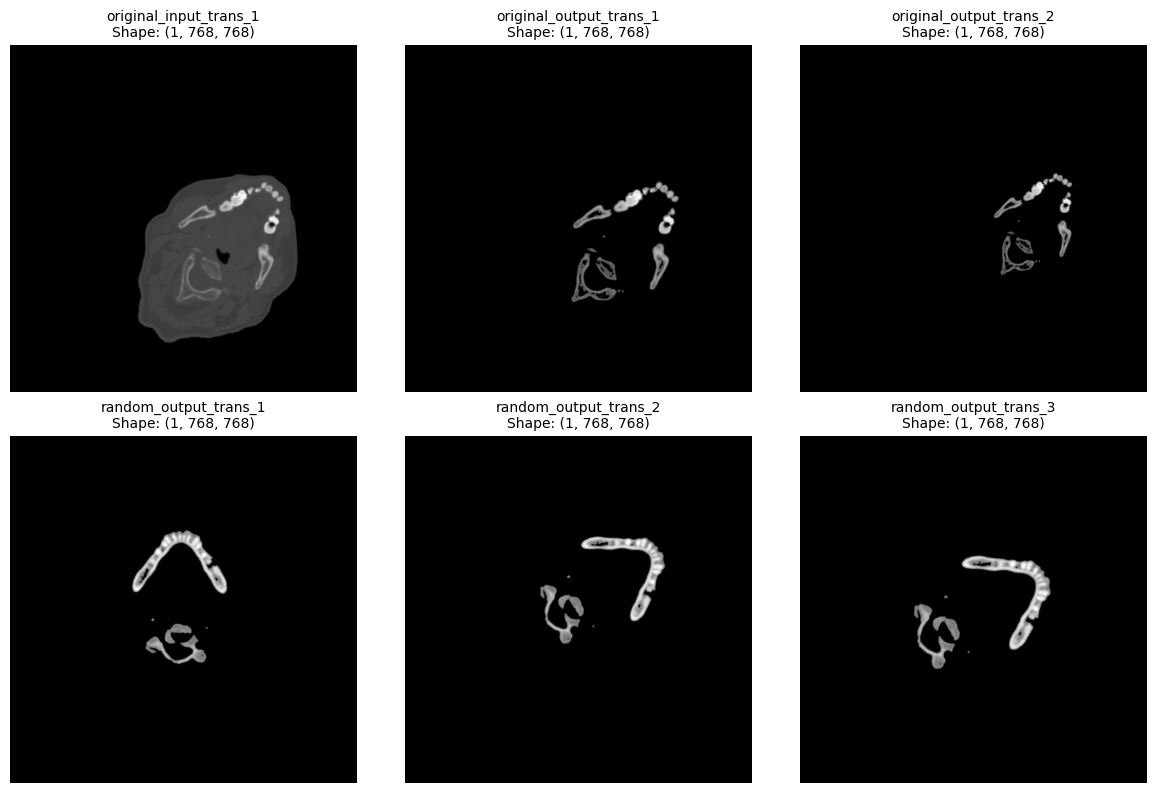

In [23]:
# import matplotlib.pyplot as plt
# import numpy as np

# Select which batch you want
k = 1

# Iterate over train_loader and pick kth batch
for i, batch in enumerate(train_loader, start=1):
    if i == k:
        selected_batch = batch
        break

# Print keys in selected batch
print(f"Keys in batch {k}:", selected_batch.keys())

# Print tensor details
for key, value in selected_batch.items():
    print(
        f"{key}: shape={value.shape}, dtype={value.dtype}, "
        f"min={value.min().item()}, max={value.max().item()}"
    )

print("\n" + "="*60)
print("VISUALIZING FIRST IMAGE FROM EACH TENSOR [0,:,:]")
print("="*60)

# Get all the keys
keys = list(selected_batch.keys())

# Calculate grid size for subplots
n_images = len(keys)
cols = 3 # 5 columns
rows = (n_images + cols - 1) // cols  # Calculate rows needed

# Create figure with subplots
fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows))

# Flatten axes array for easier indexing
if rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

# Plot each image
for idx, key in enumerate(keys):
    # Get the first image from the batch [0, :, :]
    img = selected_batch[key][0].cpu().numpy()  # Convert to numpy if it's a tensor
    
    # Plot the image
    axes[idx].imshow(img[0], cmap='gray')
    axes[idx].set_title(f'{key}\nShape: {img.shape}', fontsize=10)
    axes[idx].axis('off')
    
    # Print some statistics
    print(f"{key}:")
    print(f"  Shape: {img.shape}")
    print(f"  Min: {img.min():.4f}, Max: {img.max():.4f}")
    print()


# Hide unused subplots
for idx in range(len(keys), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


# Train Initializer

In [ ]:

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Initialize models
unet_model = UNet().to(device)
siamese_net = SiameseNetwork().to(device)
discriminator_model = Discriminator().to(device)

# Initialize optimizers
optimizer_unet = optim.Adam(unet_model.parameters(), lr=0.0005)
optimizer_siamese = optim.Adam(siamese_net.parameters(), lr=0.0005)
optimizer_discriminator = optim.Adam(discriminator_model.parameters(), lr=0.0005)

scheduler_unet = CustomLRScheduler(optimizer=optimizer_unet,start_lr=0.0005,end_lr=0.00001,decay_epochs=50)
scheduler_siamese = CustomLRScheduler(optimizer=optimizer_siamese,start_lr=0.0005,end_lr=0.00001,decay_epochs=50)
scheduler_discriminator = CustomLRScheduler(optimizer=optimizer_discriminator,start_lr=0.0005,end_lr=0.00001,decay_epochs=50)

# Initialize loss functions
bce_loss_siamese = nn.BCELoss()  # Siamese outputs probabilities
bce_loss_discriminator = nn.BCEWithLogitsLoss()  # Discriminator outputs logits
# bce_loss_siamese = nn.MSELoss()  # Siamese outputs probabilities
# bce_loss_discriminator = nn.MSELoss()  # Discriminator outputs logits
l1_loss = nn.L1Loss()
mse_loss = nn.MSELoss()

# Training history
train_history = {
    'loss_unet': [],
    'loss_siamese': [],
    'loss_discriminator': [],
    'loss_total': [],
    'L1_loss': [],
    'MSE_loss': [],
    'unet_discriminator': [],
    'unet_siamese': []
}

val_history = { key: [] for key in train_history }

# Initialize best values very large
best_l1 = float("inf")
best_mse = float("inf")

best_l1_epoch = -1
best_mse_epoch = -1


Using device: cuda


# Train Items

In [25]:
def train_step(batch):
    """
    Single training step for all models - optimized to avoid redundant UNet forward passes
    """
    # Extract batch data
    original_input_trans_1 = batch['original_input_trans_1'].to(device)
    original_output_trans_1 = batch['original_output_trans_1'].to(device)
    original_output_trans_2 = batch['original_output_trans_2'].to(device)
    random_output_trans_1 = batch['random_output_trans_1'].to(device)
    random_output_trans_2 = batch['random_output_trans_2'].to(device)
    random_output_trans_3 = batch['random_output_trans_3'].to(device)
    
    # =============================================
    # 1. UNet Training (with gradient tracking)
    # =============================================
    optimizer_unet.zero_grad()
    
    # Single forward pass for UNet
    unet_output, att_map = unet_model(original_input_trans_1)
    
    # Reconstruction losses
    loss_unet_l1 = l1_loss(unet_output, original_output_trans_1)
    loss_unet_mse = mse_loss(unet_output, original_output_trans_1)
    
    # Adversarial loss - discriminator outputs logits
    unet_adversarial_pred = discriminator_model(unet_output)
    loss_unet_adversarial = bce_loss_discriminator(
        unet_adversarial_pred, 
        torch.ones_like(unet_adversarial_pred, device=device)
    )
    
    # Similarity loss - siamese outputs probabilities
    unet_siamese_similarity = siamese_net(unet_output, original_output_trans_2)
    unet_siamese_similarity_label = torch.zeros_like(unet_siamese_similarity)
    # Since siamese outputs probability of being dissimilar,
    # and we want UNet output to be similar to target, we minimize the similarity score
    loss_unet_similarity = bce_loss_siamese(unet_siamese_similarity, unet_siamese_similarity_label)
    
    # Combined UNet loss with weights
    loss_unet_total = 1.0 * loss_unet_adversarial + 2.0 * loss_unet_similarity
    
    loss_unet_total.backward()
    # torch.nn.utils.clip_grad_norm_(unet_model.parameters(), max_norm=1.0)
    optimizer_unet.step()
    
    # =============================================
    # Save UNet output for reuse (detach from computation graph)
    # =============================================
    unet_output_detached = unet_output.detach()
    
    # =============================================
    # 2. Siamese Network Training 
    # ============================================= 
    optimizer_siamese.zero_grad()
    
    # Siamese network outputs probabilities (has sigmoid)
    sim_similarity_1 = siamese_net(random_output_trans_1, random_output_trans_2)
    sim_labels_1 = torch.zeros_like(sim_similarity_1)
    
    sim_similarity_2 = siamese_net(random_output_trans_2, random_output_trans_3)
    sim_labels_2 = torch.zeros_like(sim_similarity_2)

    dissim_similarity = siamese_net(original_output_trans_2, random_output_trans_3)
    dissim_labels = torch.ones_like(dissim_similarity)

    # Use the saved detached UNet output
    unet_dissim_similarity = siamese_net(unet_output_detached, original_output_trans_2)
    unet_dissim_labels = torch.ones_like(unet_dissim_similarity)
    
    # Use BCELoss for siamese (outputs are probabilities)
    loss_siamese_sim_1 = bce_loss_siamese(sim_similarity_1, sim_labels_1)
    loss_siamese_sim_2 = bce_loss_siamese(sim_similarity_2, sim_labels_2)
    loss_siamese_dissim = bce_loss_siamese(dissim_similarity, dissim_labels)
    loss_siamese_unet_dissim = bce_loss_siamese(unet_dissim_similarity, unet_dissim_labels)
    
    loss_siamese_total = (loss_siamese_sim_1 + loss_siamese_sim_2 + 
                          loss_siamese_dissim + loss_siamese_unet_dissim)
    
    loss_siamese_total.backward()
    # torch.nn.utils.clip_grad_norm_(siamese_net.parameters(), max_norm=1.0)
    optimizer_siamese.step()
    
    # =============================================
    # 3. Discriminator Training
    # =============================================
    optimizer_discriminator.zero_grad()
    
    # Discriminator outputs logits (no sigmoid)
    real_pred = discriminator_model(original_output_trans_2)
    real_labels = torch.ones_like(real_pred)
    
    # Use the saved detached UNet output
    fake_pred = discriminator_model(unet_output_detached)
    fake_labels = torch.zeros_like(fake_pred)
    
    # Use BCEWithLogitsLoss for discriminator (outputs are logits)
    loss_discriminator_real = bce_loss_discriminator(real_pred, real_labels)
    loss_discriminator_fake = bce_loss_discriminator(fake_pred, fake_labels)
    loss_discriminator_total = loss_discriminator_real + loss_discriminator_fake
    
    loss_discriminator_total.backward()
    # torch.nn.utils.clip_grad_norm_(discriminator_model.parameters(), max_norm=1.0)
    optimizer_discriminator.step()
    

    # =============================================
    # Return losses for logging
    # =============================================
    return {
        'loss_unet': loss_unet_total.item(),
        'loss_siamese': loss_siamese_total.item(),
        'loss_discriminator': loss_discriminator_total.item(),
        'loss_total': (loss_unet_total + loss_siamese_total + loss_discriminator_total).item(),
        'L1_loss': loss_unet_l1.item(),
        'MSE_loss': loss_unet_mse.item(),
        'unet_discriminator': loss_unet_adversarial.item(),
        'unet_siamese': loss_unet_similarity.item()
    }

In [26]:


# def train_step(batch):
#     """
#     Single training step for all models
#     """
#     # Extract batch data
#     original_input_trans_1 = batch['original_input_trans_1'].to(device)
#     original_output_trans_1 = batch['original_output_trans_1'].to(device)
#     original_output_trans_2 = batch['original_output_trans_2'].to(device)
#     random_output_trans_1 = batch['random_output_trans_1'].to(device)
#     random_output_trans_2 = batch['random_output_trans_2'].to(device)
#     random_output_trans_3 = batch['random_output_trans_3'].to(device)
    
#     # =============================================
#     # 1. Forward pass through UNet 
#     # =============================================
#     unet_output, att_map = unet_model(original_input_trans_1)
    
#     # =============================================
#     # 2. Siamese Network Training 
#     # ============================================= 
#     optimizer_siamese.zero_grad()
    
#     # Siamese network outputs probabilities (has sigmoid)
#     sim_similarity_1 = siamese_net(random_output_trans_1, random_output_trans_2)
#     sim_labels_1 = torch.zeros_like(sim_similarity_1)
    
#     sim_similarity_2 = siamese_net(random_output_trans_2, random_output_trans_3)
#     sim_labels_2 = torch.zeros_like(sim_similarity_2)

#     dissim_similarity = siamese_net(original_output_trans_2, random_output_trans_3)
#     dissim_labels = torch.ones_like(dissim_similarity)

#     unet_dissim_similarity = siamese_net(unet_output.detach(), original_output_trans_2)
#     unet_dissim_labels = torch.ones_like(unet_dissim_similarity)
    
#     # Use BCELoss for siamese (outputs are probabilities)
#     loss_siamese_sim_1 = bce_loss_siamese(sim_similarity_1, sim_labels_1)
#     loss_siamese_sim_2 = bce_loss_siamese(sim_similarity_2, sim_labels_2)
#     loss_siamese_dissim = bce_loss_siamese(dissim_similarity, dissim_labels)
#     loss_siamese_unet_dissim = bce_loss_siamese(unet_dissim_similarity, unet_dissim_labels)
    
#     loss_siamese_total = (loss_siamese_sim_1 + loss_siamese_sim_2 + 
#                           loss_siamese_dissim + loss_siamese_unet_dissim)
    
#     loss_siamese_total.backward()
#     # torch.nn.utils.clip_grad_norm_(siamese_net.parameters(), max_norm=1.0)
#     optimizer_siamese.step()
    
#     # =============================================
#     # 3. Discriminator Training
#     # =============================================
#     optimizer_discriminator.zero_grad()
    
#     # Discriminator outputs logits (no sigmoid)
#     real_pred = discriminator_model(original_output_trans_2)
#     real_labels = torch.ones_like(real_pred)
    
#     fake_pred = discriminator_model(unet_output.detach())
#     fake_labels = torch.zeros_like(fake_pred)
    
#     # Use BCEWithLogitsLoss for discriminator (outputs are logits)
#     loss_discriminator_real = bce_loss_discriminator(real_pred, real_labels)
#     loss_discriminator_fake = bce_loss_discriminator(fake_pred, fake_labels)
#     loss_discriminator_total = loss_discriminator_real + loss_discriminator_fake
    
#     loss_discriminator_total.backward()
#     # torch.nn.utils.clip_grad_norm_(discriminator_model.parameters(), max_norm=1.0)
#     optimizer_discriminator.step()
    
#     # =============================================
#     # 4. UNet Training
#     # =============================================
#     optimizer_unet.zero_grad()
    
#     # Fresh forward pass for UNet
#     unet_output_fresh, _ = unet_model(original_input_trans_1)
    
#     # Reconstruction losses
#     loss_unet_l1 = l1_loss(unet_output_fresh, original_output_trans_1)
#     loss_unet_mse = mse_loss(unet_output_fresh, original_output_trans_1)
    
#     # Adversarial loss - discriminator outputs logits
#     unet_adversarial_pred = discriminator_model(unet_output_fresh)
#     loss_unet_adversarial = bce_loss_discriminator(
#         unet_adversarial_pred, 
#         torch.ones_like(unet_adversarial_pred, device=device)
#     )
    
#     # Similarity loss - siamese outputs probabilities
#     unet_siamese_similarity = siamese_net(unet_output_fresh, original_output_trans_2)
#     unet_siamese_similarity_label = torch.zeros_like(unet_siamese_similarity)
#     # Since siamese outputs probability of being dissimilar,
#     # and we want UNet output to be similar to target, we minimize the similarity score
#     loss_unet_similarity = bce_loss_siamese(unet_siamese_similarity, unet_siamese_similarity_label)
    
#     # Combined UNet loss with weights
#     loss_unet_total = 1.0 * loss_unet_adversarial + 1.0 * loss_unet_similarity
    
#     loss_unet_total.backward()
#     # torch.nn.utils.clip_grad_norm_(unet_model.parameters(), max_norm=1.0)
#     optimizer_unet.step()
    
#     # =============================================
#     # Return losses for logging
#     # =============================================
#     return {
#         'loss_unet': loss_unet_total.item(),
#         'loss_siamese': loss_siamese_total.item(),
#         'loss_discriminator': loss_discriminator_total.item(),
#         'loss_total': (loss_unet_total + loss_siamese_total + loss_discriminator_total).item(),
#         'L1_loss': loss_unet_l1.item(),
#         'MSE_loss': loss_unet_mse.item(),
#         'unet_discriminator': loss_unet_adversarial.item(),
#         'unet_siamese': loss_unet_similarity.item()
#     }

In [27]:
# Train for one epoch

def train_epoch(dataloader, epoch):
    """
    Train for one epoch
    """
    unet_model.train()
    siamese_net.train()
    discriminator_model.train()
    
    epoch_losses = {
        'loss_unet': 0,
        'loss_siamese': 0,
        'loss_discriminator': 0,
        'loss_total': 0,
        'L1_loss': 0,
        'MSE_loss': 0,
        'unet_discriminator': 0,
        'unet_siamese': 0
    }
    
    num_batches = len(dataloader)
    
    with tqdm(dataloader, desc=f'Epoch {epoch+1}') as pbar:
        for batch_idx, batch in enumerate(pbar):
            losses = train_step(batch)
            
            # Accumulate losses
            for key in epoch_losses:
                epoch_losses[key] += losses[key]
            
            # Update progress bar
            pbar.set_postfix({
                'U': f'{losses["loss_unet"]:.6f}',
                'S': f'{losses["loss_siamese"]:.6f}',
                'D': f'{losses["loss_discriminator"]:.6f}',
                'T': f'{losses["loss_total"]:.6f}',
                'L': f'{losses["L1_loss"]:.6f}',
                'M': f'{losses["MSE_loss"]:.6f}',
                'UD': f'{losses["unet_discriminator"]:.6f}',
                'US': f'{losses["unet_siamese"]:.6f}'
            })
    
    # Average losses for the epoch
    for key in epoch_losses:
        epoch_losses[key] /= num_batches
        train_history[key].append(epoch_losses[key])
    
    return epoch_losses


In [28]:
def validatin_step(batch):
    """
    Single training step for all models - optimized to avoid redundant UNet forward passes
    """
    # Extract batch data
    original_input_trans_1 = batch['original_input_trans_1'].to(device)
    original_output_trans_1 = batch['original_output_trans_1'].to(device)
    original_output_trans_2 = batch['original_output_trans_2'].to(device)
    random_output_trans_1 = batch['random_output_trans_1'].to(device)
    random_output_trans_2 = batch['random_output_trans_2'].to(device)
    random_output_trans_3 = batch['random_output_trans_3'].to(device)
    
    # =============================================
    # 1. UNet Training (with gradient tracking)
    # =============================================
    # optimizer_unet.zero_grad()
    
    # Single forward pass for UNet
    unet_output, att_map = unet_model(original_input_trans_1)
    
    # Reconstruction losses
    loss_unet_l1 = l1_loss(unet_output, original_output_trans_1)
    loss_unet_mse = mse_loss(unet_output, original_output_trans_1)
    
    # Adversarial loss - discriminator outputs logits
    unet_adversarial_pred = discriminator_model(unet_output)
    loss_unet_adversarial = bce_loss_discriminator(
        unet_adversarial_pred, 
        torch.ones_like(unet_adversarial_pred, device=device)
    )
    
    # Similarity loss - siamese outputs probabilities
    unet_siamese_similarity = siamese_net(unet_output, original_output_trans_2)
    unet_siamese_similarity_label = torch.zeros_like(unet_siamese_similarity)
    # Since siamese outputs probability of being dissimilar,
    # and we want UNet output to be similar to target, we minimize the similarity score
    loss_unet_similarity = bce_loss_siamese(unet_siamese_similarity, unet_siamese_similarity_label)
    
    # Combined UNet loss with weights
    loss_unet_total = 1.0 * loss_unet_adversarial + 2.0 * loss_unet_similarity
    
    # loss_unet_total.backward()
    # # torch.nn.utils.clip_grad_norm_(unet_model.parameters(), max_norm=1.0)
    # optimizer_unet.step()
    
    # =============================================
    # Save UNet output for reuse (detach from computation graph)
    # =============================================
    unet_output_detached = unet_output.detach()
    
    # =============================================
    # 2. Siamese Network Training 
    # ============================================= 
    # optimizer_siamese.zero_grad()
    
    # Siamese network outputs probabilities (has sigmoid)
    sim_similarity_1 = siamese_net(random_output_trans_1, random_output_trans_2)
    sim_labels_1 = torch.zeros_like(sim_similarity_1)
    
    sim_similarity_2 = siamese_net(random_output_trans_2, random_output_trans_3)
    sim_labels_2 = torch.zeros_like(sim_similarity_2)

    dissim_similarity = siamese_net(original_output_trans_2, random_output_trans_3)
    dissim_labels = torch.ones_like(dissim_similarity)

    # Use the saved detached UNet output
    unet_dissim_similarity = siamese_net(unet_output_detached, original_output_trans_2)
    unet_dissim_labels = torch.ones_like(unet_dissim_similarity)
    
    # Use BCELoss for siamese (outputs are probabilities)
    loss_siamese_sim_1 = bce_loss_siamese(sim_similarity_1, sim_labels_1)
    loss_siamese_sim_2 = bce_loss_siamese(sim_similarity_2, sim_labels_2)
    loss_siamese_dissim = bce_loss_siamese(dissim_similarity, dissim_labels)
    loss_siamese_unet_dissim = bce_loss_siamese(unet_dissim_similarity, unet_dissim_labels)
    
    loss_siamese_total = (loss_siamese_sim_1 + loss_siamese_sim_2 + 
                          loss_siamese_dissim + loss_siamese_unet_dissim)
    
    # loss_siamese_total.backward()
    # # torch.nn.utils.clip_grad_norm_(siamese_net.parameters(), max_norm=1.0)
    # optimizer_siamese.step()
    
    # =============================================
    # 3. Discriminator Training
    # =============================================
    # optimizer_discriminator.zero_grad()
    
    # Discriminator outputs logits (no sigmoid)
    real_pred = discriminator_model(original_output_trans_2)
    real_labels = torch.ones_like(real_pred)
    
    # Use the saved detached UNet output
    fake_pred = discriminator_model(unet_output_detached)
    fake_labels = torch.zeros_like(fake_pred)
    
    # Use BCEWithLogitsLoss for discriminator (outputs are logits)
    loss_discriminator_real = bce_loss_discriminator(real_pred, real_labels)
    loss_discriminator_fake = bce_loss_discriminator(fake_pred, fake_labels)
    loss_discriminator_total = loss_discriminator_real + loss_discriminator_fake
    
    # loss_discriminator_total.backward()
    # # torch.nn.utils.clip_grad_norm_(discriminator_model.parameters(), max_norm=1.0)
    # optimizer_discriminator.step()
    

    # =============================================
    # Return losses for logging
    # =============================================
    return {
        'loss_unet': loss_unet_total.item(),
        'loss_siamese': loss_siamese_total.item(),
        'loss_discriminator': loss_discriminator_total.item(),
        'loss_total': (loss_unet_total + loss_siamese_total + loss_discriminator_total).item(),
        'L1_loss': loss_unet_l1.item(),
        'MSE_loss': loss_unet_mse.item(),
        'unet_discriminator': loss_unet_adversarial.item(),
        'unet_siamese': loss_unet_similarity.item()
    }

In [29]:
@torch.no_grad()
def validate(val_dataloader):
    """
    Validation step
    """
    unet_model.eval()
    siamese_net.eval()
    discriminator_model.eval()
    
    val_losses = {
        'loss_unet': 0,
        'loss_siamese': 0,
        'loss_discriminator': 0,
        'loss_total': 0,
        'L1_loss': 0,
        'MSE_loss': 0,
        'unet_discriminator': 0,
        'unet_siamese': 0
    }
    
    num_batches = len(val_dataloader)
    
    for batch in tqdm(val_dataloader, desc='Validation'):
        losses = validatin_step(batch)  # Same forward pass, no gradients
        
        for key in val_losses:
            val_losses[key] += losses[key]
    
    # Average validation losses
    for key in val_losses:
        val_losses[key] /= num_batches
        val_history[key].append(val_losses[key])
    
    return val_losses

In [30]:
# Save Validation Images 

def save_validation_samples(val_dataloader, epoch, save_dir='validation_samples'):
    """
    Save validation samples:
    - One .npy file with input, UNet output, and ground truth
    - One comparison image with all samples as subplots
    """
    unet_model.eval()
    
    # Create directories
    image_dir = os.path.join(save_dir, 'images')
    numpy_dir = os.path.join(save_dir, 'numpy')
    os.makedirs(image_dir, exist_ok=True)
    os.makedirs(numpy_dir, exist_ok=True)
    
    with torch.no_grad():
        # Get first batch
        batch = next(iter(val_dataloader))
        
        # Extract data
        input_tensor = batch['original_input_trans_1'].to(device)
        gt_tensor = batch['original_output_trans_1'].to(device)
        
        # Forward pass
        output_tensor, att_map = unet_model(input_tensor)
        
        # Convert to numpy
        input_np = input_tensor.cpu().numpy()
        output_np = output_tensor.cpu().numpy()
        gt_np = gt_tensor.cpu().numpy()
        
        # Save numpy file (uncompressed)
        numpy_path = os.path.join(numpy_dir, f'epoch_{epoch+1}_validation_data.npy')
        np.save(numpy_path, {
            "input": input_np,
            "unet_output": output_np,
            "ground_truth": gt_np
        })
        # print(f"Saved numpy data: {numpy_path}")
        
        # Plot all samples in one figure
        batch_size = input_np.shape[0]
        fig, axes = plt.subplots(batch_size, 3, figsize=(12, 4 * batch_size))
        
        if batch_size == 1:  # make sure axes is 2D
            axes = np.expand_dims(axes, 0)
        
        # Normalize to [0, 1] range if needed
        def normalize(img):
            img_min, img_max = img.min(), img.max()
            if img_max > img_min:
                return (img - img_min) / (img_max - img_min)
            else:
                return img
        
        for i in range(batch_size):
            inp = input_np[i]
            out = output_np[i]
            gt  = gt_np[i]
            
            # Handle channel dimensions
            if inp.ndim == 3 and inp.shape[0] == 1:  # [1, H, W] -> [H, W]
                inp, out, gt = inp[0], out[0], gt[0]
            elif inp.ndim == 3 and inp.shape[0] > 1:  # [C, H, W] -> [H, W, C]
                inp, out, gt = np.transpose(inp, (1, 2, 0)), np.transpose(out, (1, 2, 0)), np.transpose(gt, (1, 2, 0))
            
            imgs = [normalize(inp), normalize(out), normalize(gt)]
            titles = ['Input', 'UNet Output', 'Ground Truth']
            
            for j in range(3):
                axes[i, j].imshow(imgs[j], cmap='gray' if imgs[j].ndim == 2 else None)
                axes[i, j].set_title(titles[j])
                axes[i, j].axis('off')
        
        plt.tight_layout()
        comp_path = os.path.join(image_dir, f'epoch_{epoch+1}_comparison.png')
        plt.savefig(comp_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        # print(f"Saved comparison image: {comp_path}")
    
    # print(f"Validation samples saved for epoch {epoch+1}")


In [31]:
# plot training and validation losses

def plot_losses(save_dir):
    """
    Plot training and validation losses and save as PNGs.
    One combined plot + one per key.
    """
    os.makedirs(save_dir, exist_ok=True)

    print("Plotting losses...")
    
    # --- Combined plot ---
    plt.figure(figsize=(12, 8))
    for key in train_history.keys():
        plt.plot(train_history[key], label=f"Train {key}")
        if len(val_history[key]) > 0:
            plt.plot(val_history[key], label=f"Val {key}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Losses (All)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "all_losses.png"), dpi=150, bbox_inches="tight")
    plt.close()

    # --- Individual plots ---
    for key in train_history.keys():
        plt.figure(figsize=(8, 6))
        plt.plot(train_history[key], label=f"Train {key}")
        if len(val_history[key]) > 0:
            plt.plot(val_history[key], label=f"Val {key}")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title(f"Training and Validation Loss: {key}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f"{key}_loss.png"), dpi=150, bbox_inches="tight")
        plt.close()
    
    # print(f"Loss plots saved in {save_dir}")


In [32]:
# save weights function

def save_weights(epoch,num_epochs,save_dir='model_weights'):
    """
    Save last epoch weights and best validation weights.
    """
    global best_l1, best_mse, best_l1_epoch, best_mse_epoch
    os.makedirs(save_dir, exist_ok=True)

    # print(f"Saving weights at epoch {epoch+1}...")

    # --- Save best validation weights (based on L1_loss) ---
    current_val_L1 = val_history['L1_loss'][-1]  # last validation loss
    if current_val_L1 < best_l1:
        best_l1 = current_val_L1
        best_l1_epoch = epoch +1 
        torch.save({
            'epoch': epoch+1,
            'unet': unet_model.state_dict(),
            'siamese': siamese_net.state_dict(),
            'discriminator': discriminator_model.state_dict(),
            'history_val': val_history,
            'history_train': train_history
        }, os.path.join(save_dir, "best_l1_epoch.pth"))
        print(f"✅ Best L1 Loss model updated at epoch {epoch+1} with val_loss={current_val_L1:.4f}")
        
    # --- Save best validation weights (based on MSE_loss) ---
    current_val_MSE = val_history['MSE_loss'][-1]  # last validation loss
    if current_val_MSE < best_mse:
        best_mse = current_val_MSE
        best_mse_epoch = epoch + 1
        torch.save({
            'epoch': epoch+1,
            'unet': unet_model.state_dict(),
            'siamese': siamese_net.state_dict(),
            'discriminator': discriminator_model.state_dict(),
            'history_val': val_history,
            'history_train': train_history
        }, os.path.join(save_dir, "best_mse_epoch.pth"))
        print(f"✅ Best MSE Loss model updated at epoch {epoch+1} with val_loss={current_val_MSE:.4f}")
        
    # --- Save last epoch weights ---
    if (epoch + 1) == num_epochs:
        torch.save({
            'epoch': epoch+1,
            'unet': unet_model.state_dict(),
            'siamese': siamese_net.state_dict(),
            'discriminator': discriminator_model.state_dict(),
            'history_val': val_history,
            'history_train': train_history
        }, os.path.join(save_dir, "last_epoch.pth"))
        print(f"✅ Last epoch model saved at epoch {epoch+1}")
        
    
    # print(f"Weights saved in {save_dir}")    
    

# Train It

In [33]:
# Training parameters
num_epochs = 3
validate_every = 1  # Validate every N epochs
save_samples_every = 1  # Save validation samples every N epochs
save_dir = "../weaksup_Results/vw02_05_unet_simp_14njan2026"

print("Starting training...")
print(f"Total epochs: {num_epochs}")

for epoch in range(num_epochs):
    
    # Training
    train_losses = train_epoch(train_loader, epoch)
    print(
        f"UNet: {train_losses['loss_unet']:.6f} | "
        f"Siamese: {train_losses['loss_siamese']:.6f} | "
        f"Discriminator: {train_losses['loss_discriminator']:.6f} | "
        f"Total: {train_losses['loss_total']:.6f} | "
        f"L1: {train_losses['L1_loss']:.6f} | "
        f"MSE: {train_losses['MSE_loss']:.6f}"
    )
    # Validation
    val_losses = validate(val_loader)
    print(
        f"UNet: {val_losses['loss_unet']:.6f} | "
        f"Siamese: {val_losses['loss_siamese']:.6f} | "
        f"Discriminator: {val_losses['loss_discriminator']:.6f} | "
        f"Total: {val_losses['loss_total']:.6f} | "
        f"L1: {val_losses['L1_loss']:.6f} | "
        f"MSE: {val_losses['MSE_loss']:.6f}"
    )
            
    # save validation images
    if (epoch + 1) % save_samples_every == 0:
        save_validation_samples(val_loader, epoch, save_dir=save_dir)
        
    # Plot losses
    plot_losses(save_dir=save_dir)
    
    # Save weights
    save_weights(epoch,num_epochs, save_dir=save_dir)
    
    print(f"best_l1: {best_l1:.4f} at epoch {best_l1_epoch} | best_mse: {best_mse:.4f} at epoch {best_mse_epoch}")

    scheduler_unet.step()
    scheduler_siamese.step()
    scheduler_discriminator.step()

    lr_unet = optimizer_unet.param_groups[0]['lr']
    lr_siamese = optimizer_siamese.param_groups[0]['lr']
    lr_discriminator = optimizer_discriminator.param_groups[0]['lr']
    
    print(f" Learning Rates -> UNet: {lr_unet:.6f}, Siamese: {lr_siamese:.6f}, Discriminator: {lr_discriminator:.6f}")

    print("-" * 150)

print("Training completed!")


Starting training...
Total epochs: 3


Epoch 1: 100%|██████████| 75/75 [00:22<00:00,  3.33it/s, U=5.406025, S=4.384510, D=0.074753, T=9.865288, L=0.345394, M=0.149311, UD=3.623389, US=0.891318]  


UNet: 3.995345 | Siamese: 3.733944 | Discriminator: 0.699060 | Total: 8.428349 | L1: 0.364231 | MSE: 0.161530


Validation: 100%|██████████| 25/25 [00:04<00:00,  5.76it/s]


UNet: 7.981643 | Siamese: 2.580487 | Discriminator: 3.846825 | Total: 14.408955 | L1: 0.356490 | MSE: 0.167502
Plotting losses...
✅ Best L1 Loss model updated at epoch 1 with val_loss=0.3565
✅ Best MSE Loss model updated at epoch 1 with val_loss=0.1675
best_l1: 0.3565 at epoch 1 | best_mse: 0.1675 at epoch 1
 Learning Rates -> UNet: 0.000490, Siamese: 0.000500, Discriminator: 0.000500
------------------------------------------------------------------------------------------------------------------------------------------------------


...

UNet: 45.552208 | Siamese: 2.162299 | Discriminator: 13.477996 | Total: 61.192503 | L1: 0.334989 | MSE: 0.174907
Plotting losses...
✅ Best L1 Loss model updated at epoch 2 with val_loss=0.3350
best_l1: 0.3350 at epoch 2 | best_mse: 0.1675 at epoch 1
 Learning Rates -> UNet: 0.000480, Siamese: 0.000500, Discriminator: 0.000500
------------------------------------------------------------------------------------------------------------------------------------------------------


Epoch 3: 100%|██████████| 75/75 [00:18<00:00,  3.99it/s, U=7.484363, S=2.598484, D=0.008378, T=10.091226, L=0.340942, M=0.142739, UD=6.612093, US=0.436135]  


UNet: 8.077277 | Siamese: 3.037036 | Discriminator: 0.007134 | Total: 11.121446 | L1: 0.360507 | MSE: 0.155478


Validation: 100%|██████████| 25/25 [00:04<00:00,  5.60it/s]


UNet: 19.742963 | Siamese: 2.481614 | Discriminator: 34.856974 | Total: 57.081550 | L1: 0.357226 | MSE: 0.148329
Plotting losses...
✅ Best MSE Loss model updated at epoch 3 with val_loss=0.1483
✅ Last epoch model saved at epoch 3
best_l1: 0.3350 at epoch 2 | best_mse: 0.1483 at epoch 3
 Learning Rates -> UNet: 0.000471, Siamese: 0.000500, Discriminator: 0.000500
------------------------------------------------------------------------------------------------------------------------------------------------------
Training completed!


# Eval codes 

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Initialize models
unet_model_new = UNet().to(device)
# siamese_net = SiameseNetwork().to(device)
# discriminator_model = Discriminator().to(device)

# =============================================
# LOAD SAVED WEIGHTS
# =============================================
checkpoint_path = r"C:\Users\VIVEK BOHANE\Desktop\WS_I2I\pix2pix_Results\Out_01_unet_simp_12nov\best_l1_epoch.pth"  # Update this path

checkpoint = torch.load(checkpoint_path, map_location=device)

# Load model weights
unet_model_new.load_state_dict(checkpoint['unet'])
# siamese_net.load_state_dict(checkpoint['siamese'])
# discriminator_model.load_state_dict(checkpoint['discriminator'])

# Load history if needed
train_history = checkpoint['history_train']
val_history = checkpoint['history_val']
loaded_epoch = checkpoint['epoch']

print(f"✅ Successfully loaded checkpoint from epoch {loaded_epoch}")
print(f"   Best validation L1 loss: {val_history['L1_loss'][-1]:.4f}")


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# =============================================
# LOAD WEAKLY SUPERVISED MODEL
# =============================================
print("\n🔵 Loading Weakly Supervised Model...")
unet_model_weak = UNet().to(device)
siamese_net = SiameseNetwork().to(device)
discriminator_model = Discriminator().to(device)

checkpoint_path_weak = r"C:\Users\VIVEK BOHANE\Desktop\WS_I2I\weaksup_Results\vw02_Out_06_unet_simp_30nov\best_l1_epoch.pth"
checkpoint_weak = torch.load(checkpoint_path_weak, map_location=device)

unet_model_weak.load_state_dict(checkpoint_weak['unet'])
siamese_net.load_state_dict(checkpoint_weak['siamese'])
discriminator_model.load_state_dict(checkpoint_weak['discriminator'])

train_history_weak = checkpoint_weak['history_train']
val_history_weak = checkpoint_weak['history_val']
loaded_epoch_weak = checkpoint_weak['epoch']

print(f"✅ Weakly Supervised Model loaded from epoch {loaded_epoch_weak}")
print(f"   Best validation L1 loss: {val_history_weak['L1_loss'][-1]:.4f}")

unet_model_weak.eval()
siamese_net.eval()
discriminator_model.eval()

# =============================================
# LOAD SUPERVISED MODEL
# =============================================
print("\n🟢 Loading Supervised Model...")
unet_model_sup = UNet().to(device)

checkpoint_path_sup = r"C:\Users\VIVEK BOHANE\Desktop\WS_I2I\pix2pix_Results\Out_01_unet_simp_12nov\best_l1_epoch.pth"
checkpoint_sup = torch.load(checkpoint_path_sup, map_location=device)

unet_model_sup.load_state_dict(checkpoint_sup['unet'])

train_history_sup = checkpoint_sup['history_train']
val_history_sup = checkpoint_sup['history_val']
loaded_epoch_sup = checkpoint_sup['epoch']

print(f"✅ Supervised Model loaded from epoch {loaded_epoch_sup}")
print(f"   Best validation L1 loss: {val_history_sup['L1_loss'][-1]:.4f}")

unet_model_sup.eval()


In [ ]:

# =============================================
# COMPARISON EVALUATION FUNCTION
# =============================================
def compare_models(batch, batch_idx=0):
    """
    Compare both UNet models on a specific batch image
    
    Args:
        batch: Dictionary containing batch data
        batch_idx: Index of the image within the batch to visualize
    """
    with torch.no_grad():
        # Move data to device
        original_input = batch['original_input_trans_1'].to(device)
        ground_truth = batch['original_output_trans_1'].to(device)
        
        # Get predictions from both models
        output_weak, _ = unet_model_weak(original_input)
        output_sup, _ = unet_model_sup(original_input)
        
        # Calculate metrics for weakly supervised model
        l1_weak = nn.L1Loss()(output_weak, ground_truth)
        mse_weak = nn.MSELoss()(output_weak, ground_truth)
        
        # Calculate metrics for supervised model
        l1_sup = nn.L1Loss()(output_sup, ground_truth)
        mse_sup = nn.MSELoss()(output_sup, ground_truth)
        
        print(f"\n{'='*70}")
        print(f"📊 Comparison Metrics for Image {batch_idx}:")
        print(f"{'='*70}")
        print(f"🔵 Weakly Supervised Model:")
        print(f"   L1 Loss:  {l1_weak.item():.6f}")
        print(f"   MSE Loss: {mse_weak.item():.6f}")
        print(f"\n🟢 Supervised Model:")
        print(f"   L1 Loss:  {l1_sup.item():.6f}")
        print(f"   MSE Loss: {mse_sup.item():.6f}")
        print(f"\n📈 Difference:")
        print(f"   ΔL1:  {(l1_weak.item() - l1_sup.item()):.6f} {'(Weak worse)' if l1_weak > l1_sup else '(Weak better)'}")
        print(f"   ΔMSE: {(mse_weak.item() - mse_sup.item()):.6f} {'(Weak worse)' if mse_weak > mse_sup else '(Weak better)'}")
        print(f"{'='*70}")
        
        # Convert tensors to numpy for visualization
        input_img = original_input[batch_idx].cpu().numpy()
        output_weak_img = output_weak[batch_idx].cpu().numpy()
        output_sup_img = output_sup[batch_idx].cpu().numpy()
        gt_img = ground_truth[batch_idx].cpu().numpy()
        
        # Handle different image formats (C, H, W) or (H, W, C)
        if input_img.shape[0] in [1, 3]:  # Channels first
            input_img = input_img.transpose(1, 2, 0)
            output_weak_img = output_weak_img.transpose(1, 2, 0)
            output_sup_img = output_sup_img.transpose(1, 2, 0)
            gt_img = gt_img.transpose(1, 2, 0)
        
        # Squeeze if grayscale
        if input_img.shape[-1] == 1:
            input_img = input_img.squeeze(-1)
            output_weak_img = output_weak_img.squeeze(-1)
            output_sup_img = output_sup_img.squeeze(-1)
            gt_img = gt_img.squeeze(-1)
        
        # Normalize to [0, 1] for display
        def normalize_img(img):
            # img_min, img_max = img.min(), img.max()
            # if img_max > img_min:
            #     return (img - img_min) / (img_max - img_min)
            return img
        
        input_img = normalize_img(input_img)
        output_weak_img = normalize_img(output_weak_img)
        output_sup_img = normalize_img(output_sup_img)
        gt_img = normalize_img(gt_img)
        
        # Calculate difference maps
        diff_weak = np.abs(output_weak_img - gt_img)
        diff_sup = np.abs(output_sup_img - gt_img)
        
        # Visualize - 2 rows, 3 columns
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        cmap = 'gray' if len(input_img.shape) == 2 else None
        
        # Row 1: Input, Ground Truth, Model Comparison
        axes[0, 0].imshow(input_img, cmap=cmap)
        axes[0, 0].set_title('Input Image', fontsize=14, fontweight='bold')
        axes[0, 0].axis('off')
        plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=axes[0, 0], fraction=0.046)
        
        axes[1, 0].imshow(gt_img, cmap=cmap)
        axes[1, 0].set_title('Ground Truth', fontsize=14, fontweight='bold')
        axes[1, 0].axis('off')
        plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=axes[1, 0], fraction=0.046)
        
        # Side-by-side model outputs
        axes[0, 2].imshow(output_weak_img, cmap=cmap)
        axes[0, 2].set_title(f'🔵 Weakly Supervised Output\nL1: {l1_weak.item():.4f} | MSE: {mse_weak.item():.4f}', 
                             fontsize=12, fontweight='bold')
        axes[0, 2].axis('off')
        plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=axes[0, 2], fraction=0.046)
        
        # Row 2: Supervised output and difference maps
        axes[0, 1].imshow(output_sup_img, cmap=cmap)
        axes[0, 1].set_title(f'🟢 Supervised Output\nL1: {l1_sup.item():.4f} | MSE: {mse_sup.item():.4f}', 
                            fontsize=12, fontweight='bold')
        axes[0, 1].axis('off')
        plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=axes[0, 1], fraction=0.046)
        
        im1 = axes[1, 2].imshow(diff_weak, cmap='hot', vmin=0, vmax=max(diff_weak.max(), diff_sup.max()))
        axes[1, 2].set_title(f'🔵 Weak Sup - Abs Diff\nMean: {diff_weak.mean():.4f}', 
                            fontsize=12, fontweight='bold')
        axes[1, 2].axis('off')
        plt.colorbar(im1, ax=axes[1, 1], fraction=0.046)
        
        im2 = axes[1, 1].imshow(diff_sup, cmap='hot', vmin=0, vmax=max(diff_weak.max(), diff_sup.max()))
        axes[1, 1].set_title(f'🟢 Supervised - Abs Diff\nMean: {diff_sup.mean():.4f}', 
                            fontsize=12, fontweight='bold')
        axes[1, 1].axis('off')
        plt.colorbar(im2, ax=axes[1, 2], fraction=0.046)
        
        plt.suptitle(f'Model Comparison - Batch Image {batch_idx}', 
                     fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.show()
        
        return {
            'input': input_img,
            'output_weak': output_weak_img,
            'output_sup': output_sup_img,
            'ground_truth': gt_img,
            'diff_weak': diff_weak,
            'diff_sup': diff_sup,
            'metrics': {
                'weak': {'l1': l1_weak.item(), 'mse': mse_weak.item()},
                'sup': {'l1': l1_sup.item(), 'mse': mse_sup.item()}
            }
        }

# =============================================
# EVALUATE FIRST BATCH
# =============================================
print(f"\n{'='*70}")
print("🔍 Evaluating first batch from validation set...")
print(f"{'='*70}\n")

for batch_num, batch in enumerate(val_loader):
    print(f"Batch size: {batch['original_input_trans_1'].shape[0]}")
    
    # Evaluate all images in the first batch
    for i in range(batch['original_input_trans_1'].shape[0]):
        results = compare_models(batch, batch_idx=i)
    
    break  # Only process first batch

# ======

# interative

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.widgets import RectangleSelector, Button
from matplotlib.lines import Line2D
import matplotlib.patches as patches

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# =============================================
# LOAD MODELS
# =============================================
print("\n🔵 Loading Weakly Supervised Model...")
unet_model_weak = UNet().to(device)
siamese_net = SiameseNetwork().to(device)
discriminator_model = Discriminator().to(device)

checkpoint_path_weak = r"C:\Users\VIVEK BOHANE\Desktop\WS_I2I\weaksup_Results\vw02_Out_06_unet_simp_30nov\best_l1_epoch.pth"
checkpoint_weak = torch.load(checkpoint_path_weak, map_location=device)

unet_model_weak.load_state_dict(checkpoint_weak['unet'])
siamese_net.load_state_dict(checkpoint_weak['siamese'])
discriminator_model.load_state_dict(checkpoint_weak['discriminator'])

print(f"✅ Weakly Supervised Model loaded from epoch {checkpoint_weak['epoch']}")

unet_model_weak.eval()
siamese_net.eval()
discriminator_model.eval()

print("\n🟢 Loading Supervised Model...")
unet_model_sup = UNet().to(device)

checkpoint_path_sup = r"C:\Users\VIVEK BOHANE\Desktop\WS_I2I\pix2pix_Results\Out_01_unet_simp_12nov\best_l1_epoch.pth"
checkpoint_sup = torch.load(checkpoint_path_sup, map_location=device)

unet_model_sup.load_state_dict(checkpoint_sup['unet'])

print(f"✅ Supervised Model loaded from epoch {checkpoint_sup['epoch']}")

unet_model_sup.eval()

# =============================================
# GLOBAL STORAGE
# =============================================
stored_images = {
    'input': None,
    'ground_truth': None,
    'output_weak': None,
    'output_sup': None,
    'diff_weak': None,
    'diff_sup': None
}

# =============================================
# MAIN COMPARISON FUNCTION
# =============================================
def compare_models_and_store(batch, batch_idx=0):
    """
    Compare both UNet models and store all image data
    """
    global stored_images
    
    with torch.no_grad():
        original_input = batch['original_input_trans_1'].to(device)
        ground_truth = batch['original_output_trans_1'].to(device)
        
        output_weak, _ = unet_model_weak(original_input)
        output_sup, _ = unet_model_sup(original_input)
        
        l1_weak = nn.L1Loss()(output_weak, ground_truth)
        mse_weak = nn.MSELoss()(output_weak, ground_truth)
        l1_sup = nn.L1Loss()(output_sup, ground_truth)
        mse_sup = nn.MSELoss()(output_sup, ground_truth)
        
        print(f"\n{'='*70}")
        print(f"📊 Comparison Metrics for Image {batch_idx}:")
        print(f"{'='*70}")
        print(f"🔵 Weakly Supervised: L1={l1_weak.item():.6f}, MSE={mse_weak.item():.6f}")
        print(f"🟢 Supervised:        L1={l1_sup.item():.6f}, MSE={mse_sup.item():.6f}")
        print(f"{'='*70}")
        
        # Convert to numpy
        input_img = original_input[batch_idx].cpu().numpy()
        output_weak_img = output_weak[batch_idx].cpu().numpy()
        output_sup_img = output_sup[batch_idx].cpu().numpy()
        gt_img = ground_truth[batch_idx].cpu().numpy()
        
        if input_img.shape[0] in [1, 3]:
            input_img = input_img.transpose(1, 2, 0)
            output_weak_img = output_weak_img.transpose(1, 2, 0)
            output_sup_img = output_sup_img.transpose(1, 2, 0)
            gt_img = gt_img.transpose(1, 2, 0)
        
        if input_img.shape[-1] == 1:
            input_img = input_img.squeeze(-1)
            output_weak_img = output_weak_img.squeeze(-1)
            output_sup_img = output_sup_img.squeeze(-1)
            gt_img = gt_img.squeeze(-1)
        
        def normalize_img(img):
            img_min, img_max = img.min(), img.max()
            if img_max > img_min:
                return (img - img_min) / (img_max - img_min)
            return img
        
        input_img = normalize_img(input_img)
        output_weak_img = normalize_img(output_weak_img)
        output_sup_img = normalize_img(output_sup_img)
        gt_img = normalize_img(gt_img)
        
        diff_weak = np.abs(output_weak_img - gt_img)
        diff_sup = np.abs(output_sup_img - gt_img)
        
        # STORE GLOBALLY
        stored_images['input'] = input_img.copy()
        stored_images['ground_truth'] = gt_img.copy()
        stored_images['output_weak'] = output_weak_img.copy()
        stored_images['output_sup'] = output_sup_img.copy()
        stored_images['diff_weak'] = diff_weak.copy()
        stored_images['diff_sup'] = diff_sup.copy()
        
        # Visualize
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        cmap = 'gray' if len(input_img.shape) == 2 else None
        
        axes[0, 0].imshow(input_img, cmap=cmap)
        axes[0, 0].set_title('Input Image', fontsize=14, fontweight='bold')
        axes[0, 0].axis('off')
        
        axes[1, 0].imshow(gt_img, cmap=cmap)
        axes[1, 0].set_title('Ground Truth', fontsize=14, fontweight='bold')
        axes[1, 0].axis('off')
        
        axes[0, 2].imshow(output_weak_img, cmap=cmap)
        axes[0, 2].set_title(f'🔵 Weakly Supervised\nL1: {l1_weak.item():.4f}', fontsize=12, fontweight='bold')
        axes[0, 2].axis('off')
        
        axes[0, 1].imshow(output_sup_img, cmap=cmap)
        axes[0, 1].set_title(f'🟢 Supervised\nL1: {l1_sup.item():.4f}', fontsize=12, fontweight='bold')
        axes[0, 1].axis('off')
        
        im1 = axes[1, 2].imshow(diff_weak, cmap='hot')
        axes[1, 2].set_title(f'🔵 Weak - Abs Diff', fontsize=12, fontweight='bold')
        axes[1, 2].axis('off')
        plt.colorbar(im1, ax=axes[1, 2], fraction=0.046)
        
        im2 = axes[1, 1].imshow(diff_sup, cmap='hot')
        axes[1, 1].set_title(f'🟢 Sup - Abs Diff', fontsize=12, fontweight='bold')
        axes[1, 1].axis('off')
        plt.colorbar(im2, ax=axes[1, 1], fraction=0.046)
        
        plt.suptitle(f'Model Comparison', fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.show()
        
        print("\n✅ Images stored! Now you can use interactive selection tools.")

# =============================================
# INTERACTIVE RECTANGLE SELECTOR
# =============================================
class InteractiveRectangleSelector:
    def __init__(self):
        self.x1 = None
        self.y1 = None
        self.x2 = None
        self.y2 = None
        
    def select_rectangle(self):
        """
        Interactive rectangle selection on ground truth image
        """
        if stored_images['ground_truth'] is None:
            print("❌ No images stored! Run compare_models_and_store() first.")
            return
        
        print("\n" + "="*70)
        print("🖱️  INTERACTIVE RECTANGLE SELECTION")
        print("="*70)
        print("Instructions:")
        print("  1. Click and drag to draw a rectangle")
        print("  2. Release to finalize selection")
        print("  3. Close the window to proceed")
        print("="*70 + "\n")
        
        fig, ax = plt.subplots(figsize=(12, 10))
        cmap = 'gray' if len(stored_images['ground_truth'].shape) == 2 else None
        ax.imshow(stored_images['ground_truth'], cmap=cmap)
        ax.set_title('Select Rectangle ROI (Click & Drag)', fontsize=14, fontweight='bold')
        
        def onselect(eclick, erelease):
            self.x1, self.y1 = int(eclick.xdata), int(eclick.ydata)
            self.x2, self.y2 = int(erelease.xdata), int(erelease.ydata)
            print(f"✓ Selected: ({self.x1}, {self.y1}) to ({self.x2}, {self.y2})")
        
        selector = RectangleSelector(
            ax, onselect,
            useblit=True,
            button=[1],  # Left mouse button
            minspanx=5, minspany=5,
            spancoords='pixels',
            interactive=True,
            props=dict(facecolor='red', edgecolor='red', alpha=0.3, fill=True)
        )
        
        plt.show()
        
        if self.x1 is not None:
            self.analyze_roi()
    
    def analyze_roi(self):
        """Analyze the selected ROI"""
        x1, y1, x2, y2 = self.x1, self.y1, self.x2, self.y2
        
        # Ensure correct order
        x1, x2 = min(x1, x2), max(x1, x2)
        y1, y2 = min(y1, y2), max(y1, y2)
        
        # Extract ROIs
        gt_roi = stored_images['ground_truth'][y1:y2, x1:x2]
        weak_roi = stored_images['output_weak'][y1:y2, x1:x2]
        sup_roi = stored_images['output_sup'][y1:y2, x1:x2]
        input_roi = stored_images['input'][y1:y2, x1:x2]
        
        print(f"\n{'='*70}")
        print(f"🔍 ROI Analysis - Rectangle ({x1},{y1}) to ({x2},{y2})")
        print(f"   ROI Size: {x2-x1} x {y2-y1} pixels")
        print(f"{'='*70}")
        print(f"Ground Truth  - Mean: {gt_roi.mean():.4f}, Std: {gt_roi.std():.4f}")
        print(f"Weakly Sup    - Mean: {weak_roi.mean():.4f}, Std: {weak_roi.std():.4f}")
        print(f"Supervised    - Mean: {sup_roi.mean():.4f}, Std: {sup_roi.std():.4f}")
        
        # Visualize
        fig = plt.figure(figsize=(20, 14))
        gs = fig.add_gridspec(4, 4, hspace=0.35, wspace=0.3)
        
        cmap = 'gray' if len(stored_images['ground_truth'].shape) == 2 else None
        
        # Row 1: Full images with rectangles
        for idx, (img, title, col) in enumerate([
            (stored_images['ground_truth'], 'Ground Truth', 0),
            (stored_images['output_weak'], '🔵 Weakly Supervised', 1),
            (stored_images['output_sup'], '🟢 Supervised', 2),
            (stored_images['input'], 'Input', 3)
        ]):
            ax = fig.add_subplot(gs[0, col])
            ax.imshow(img, cmap=cmap)
            rect = Rectangle((x1, y1), x2-x1, y2-y1, linewidth=3, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.axis('off')
        
        # Row 2: Zoomed ROIs
        for idx, (roi, title, col) in enumerate([
            (gt_roi, f'GT Zoomed\nMean: {gt_roi.mean():.4f}', 0),
            (weak_roi, f'🔵 Weak Zoomed\nMean: {weak_roi.mean():.4f}', 1),
            (sup_roi, f'🟢 Sup Zoomed\nMean: {sup_roi.mean():.4f}', 2),
            (input_roi, f'Input Zoomed\nMean: {input_roi.mean():.4f}', 3)
        ]):
            ax = fig.add_subplot(gs[1, col])
            ax.imshow(roi, cmap=cmap)
            ax.set_title(title, fontsize=11, fontweight='bold')
            ax.axis('off')
        
        # Row 3: Histograms
        ax_hist1 = fig.add_subplot(gs[2, :2])
        ax_hist1.hist(gt_roi.flatten(), bins=50, alpha=0.5, color='black', label='Ground Truth', density=True)
        ax_hist1.hist(weak_roi.flatten(), bins=50, alpha=0.5, color='blue', label='Weakly Sup', density=True)
        ax_hist1.hist(sup_roi.flatten(), bins=50, alpha=0.5, color='green', label='Supervised', density=True)
        ax_hist1.set_xlabel('Intensity', fontsize=11)
        ax_hist1.set_ylabel('Normalized Frequency', fontsize=11)
        ax_hist1.set_title('ROI Intensity Histogram', fontsize=12, fontweight='bold')
        ax_hist1.legend()
        ax_hist1.grid(True, alpha=0.3)
        
        # Difference histogram
        ax_hist2 = fig.add_subplot(gs[2, 2:])
        diff_weak_roi = (weak_roi - gt_roi).flatten()
        diff_sup_roi = (sup_roi - gt_roi).flatten()
        ax_hist2.hist(diff_weak_roi, bins=50, alpha=0.6, color='blue', label=f'Weak-GT (MAE: {np.abs(diff_weak_roi).mean():.4f})', density=True)
        ax_hist2.hist(diff_sup_roi, bins=50, alpha=0.6, color='green', label=f'Sup-GT (MAE: {np.abs(diff_sup_roi).mean():.4f})', density=True)
        ax_hist2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
        ax_hist2.set_xlabel('Difference from GT', fontsize=11)
        ax_hist2.set_ylabel('Normalized Frequency', fontsize=11)
        ax_hist2.set_title('Error Distribution', fontsize=12, fontweight='bold')
        ax_hist2.legend()
        ax_hist2.grid(True, alpha=0.3)
        
        # Row 4: Intensity profiles
        ax_prof1 = fig.add_subplot(gs[3, :2])
        x_profile_gt = gt_roi.mean(axis=0)
        x_profile_weak = weak_roi.mean(axis=0)
        x_profile_sup = sup_roi.mean(axis=0)
        
        ax_prof1.plot(x_profile_gt, 'k-', linewidth=2, label='Ground Truth')
        ax_prof1.plot(x_profile_weak, 'b--', linewidth=2, label='Weakly Supervised')
        ax_prof1.plot(x_profile_sup, 'g-.', linewidth=2, label='Supervised')
        ax_prof1.set_xlabel('X Position', fontsize=11)
        ax_prof1.set_ylabel('Mean Intensity', fontsize=11)
        ax_prof1.set_title('Horizontal Profile (averaged vertically)', fontsize=12, fontweight='bold')
        ax_prof1.legend()
        ax_prof1.grid(True, alpha=0.3)
        
        ax_prof2 = fig.add_subplot(gs[3, 2:])
        y_profile_gt = gt_roi.mean(axis=1)
        y_profile_weak = weak_roi.mean(axis=1)
        y_profile_sup = sup_roi.mean(axis=1)
        
        ax_prof2.plot(y_profile_gt, 'k-', linewidth=2, label='Ground Truth')
        ax_prof2.plot(y_profile_weak, 'b--', linewidth=2, label='Weakly Supervised')
        ax_prof2.plot(y_profile_sup, 'g-.', linewidth=2, label='Supervised')
        ax_prof2.set_xlabel('Y Position', fontsize=11)
        ax_prof2.set_ylabel('Mean Intensity', fontsize=11)
        ax_prof2.set_title('Vertical Profile (averaged horizontally)', fontsize=12, fontweight='bold')
        ax_prof2.legend()
        ax_prof2.grid(True, alpha=0.3)
        
        plt.suptitle(f'ROI Analysis: ({x1},{y1}) to ({x2},{y2})', fontsize=14, fontweight='bold')
        plt.show()

# =============================================
# INTERACTIVE LINE SELECTOR
# =============================================
class InteractiveLineSelector:
    def __init__(self):
        self.points = []
        self.fig = None
        self.ax = None
        self.line = None
        
    def select_line(self):
        """
        Interactive line selection
        """
        if stored_images['ground_truth'] is None:
            print("❌ No images stored! Run compare_models_and_store() first.")
            return
        
        print("\n" + "="*70)
        print("🖱️  INTERACTIVE LINE SELECTION")
        print("="*70)
        print("Instructions:")
        print("  1. Click to set START point")
        print("  2. Click to set END point")
        print("  3. Close window to analyze")
        print("="*70 + "\n")
        
        self.fig, self.ax = plt.subplots(figsize=(12, 10))
        cmap = 'gray' if len(stored_images['ground_truth'].shape) == 2 else None
        self.ax.imshow(stored_images['ground_truth'], cmap=cmap)
        self.ax.set_title('Select Line (2 clicks: start → end)', fontsize=14, fontweight='bold')
        
        self.fig.canvas.mpl_connect('button_press_event', self.onclick)
        plt.show()
        
        if len(self.points) == 2:
            self.analyze_line()
    
    def onclick(self, event):
        if event.inaxes != self.ax:
            return
        
        x, y = int(event.xdata), int(event.ydata)
        self.points.append((x, y))
        
        # Plot point
        self.ax.plot(x, y, 'ro', markersize=10)
        
        if len(self.points) == 1:
            print(f"✓ Start point: ({x}, {y})")
        elif len(self.points) == 2:
            print(f"✓ End point: ({x}, {y})")
            # Draw line
            x1, y1 = self.points[0]
            x2, y2 = self.points[1]
            self.ax.plot([x1, x2], [y1, y2], 'r-', linewidth=2)
            self.fig.canvas.draw()
            print("✓ Line complete! Close window to analyze.")
    
    def analyze_line(self):
        """Analyze the selected line"""
        x1, y1 = self.points[0]
        x2, y2 = self.points[1]
        
        print(f"\n{'='*70}")
        print(f"📏 Line Profile Analysis - From ({x1},{y1}) to ({x2},{y2})")
        print(f"{'='*70}")
        
        # Get line coordinates
        def get_line_coords(x1, y1, x2, y2):
            coords = []
            dx = abs(x2 - x1)
            dy = abs(y2 - y1)
            sx = 1 if x1 < x2 else -1
            sy = 1 if y1 < y2 else -1
            err = dx - dy
            
            x, y = x1, y1
            while True:
                coords.append((x, y))
                if x == x2 and y == y2:
                    break
                e2 = 2 * err
                if e2 > -dy:
                    err -= dy
                    x += sx
                if e2 < dx:
                    err += dx
                    y += sy
            return coords
        
        line_coords = get_line_coords(x1, y1, x2, y2)
        
        # Extract profiles
        gt_profile = []
        weak_profile = []
        sup_profile = []
        input_profile = []
        
        for x, y in line_coords:
            if 0 <= y < stored_images['ground_truth'].shape[0] and 0 <= x < stored_images['ground_truth'].shape[1]:
                gt_profile.append(stored_images['ground_truth'][y, x])
                weak_profile.append(stored_images['output_weak'][y, x])
                sup_profile.append(stored_images['output_sup'][y, x])
                input_profile.append(stored_images['input'][y, x])
        
        gt_profile = np.array(gt_profile)
        weak_profile = np.array(weak_profile)
        sup_profile = np.array(sup_profile)
        input_profile = np.array(input_profile)
        
        print(f"Profile Length: {len(gt_profile)} pixels")
        print(f"Ground Truth - Mean: {gt_profile.mean():.4f}, Std: {gt_profile.std():.4f}")
        print(f"Weakly Sup   - Mean: {weak_profile.mean():.4f}, Std: {weak_profile.std():.4f}")
        print(f"Supervised   - Mean: {sup_profile.mean():.4f}, Std: {sup_profile.std():.4f}")
        
        # Visualize
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
        
        cmap = 'gray' if len(stored_images['ground_truth'].shape) == 2 else None
        
        # Row 1: Images with line overlay
        for idx, (img, title, col) in enumerate([
            (stored_images['ground_truth'], 'Ground Truth', 0),
            (stored_images['output_weak'], '🔵 Weakly Supervised', 1),
            (stored_images['output_sup'], '🟢 Supervised', 2)
        ]):
            ax = fig.add_subplot(gs[0, col])
            ax.imshow(img, cmap=cmap)
            ax.plot([x1, x2], [y1, y2], 'r-', linewidth=3, marker='o', markersize=8)
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.axis('off')
        
        # Row 2: Intensity profiles
        distance = np.arange(len(gt_profile))
        
        ax1 = fig.add_subplot(gs[1, :])
        ax1.plot(distance, gt_profile, 'k-', linewidth=2.5, label='Ground Truth', marker='.')
        ax1.plot(distance, weak_profile, 'b--', linewidth=2, label='Weakly Supervised', marker='.')
        ax1.plot(distance, sup_profile, 'g-.', linewidth=2, label='Supervised', marker='.')
        ax1.set_xlabel('Distance along line (pixels)', fontsize=12)
        ax1.set_ylabel('Intensity', fontsize=12)
        ax1.set_title(f'Intensity Profile Along Line', fontsize=14, fontweight='bold')
        ax1.legend(fontsize=11)
        ax1.grid(True, alpha=0.3)
        
        # Row 3: Difference and histogram
        diff_weak = np.abs(weak_profile - gt_profile)
        diff_sup = np.abs(sup_profile - gt_profile)
        
        ax2 = fig.add_subplot(gs[2, :2])
        ax2.plot(distance, diff_weak, 'b-', linewidth=2, marker='.', label=f'Weak-GT (MAE: {diff_weak.mean():.4f})')
        ax2.plot(distance, diff_sup, 'g-', linewidth=2, marker='.', label=f'Sup-GT (MAE: {diff_sup.mean():.4f})')
        ax2.set_xlabel('Distance along line (pixels)', fontsize=12)
        ax2.set_ylabel('Absolute Difference', fontsize=12)
        ax2.set_title('Error Along Line', fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11)
        ax2.grid(True, alpha=0.3)
        
        ax3 = fig.add_subplot(gs[2, 2])
        ax3.hist(gt_profile, bins=30, alpha=0.5, color='black', label='GT', density=True)
        ax3.hist(weak_profile, bins=30, alpha=0.5, color='blue', label='Weak', density=True)
        ax3.hist(sup_profile, bins=30, alpha=0.5, color='green', label='Sup', density=True)
        ax3.set_xlabel('Intensity', fontsize=11)
        ax3.set_ylabel('Density', fontsize=11)
        ax3.set_title('Intensity Histogram', fontsize=12, fontweight='bold')
        ax3.legend(fontsize=9)
        ax3.grid(True, alpha=0.3)
        
        plt.suptitle(f'Line Analysis: ({x1},{y1}) → ({x2},{y2})', fontsize=14, fontweight='bold')
        plt.show()

# =============================================
# CONVENIENCE FUNCTIONS
# =============================================
def interactive_rectangle():
    """Launch interactive rectangle selector"""
    selector = InteractiveRectangleSelector()
    selector.select_rectangle()

def interactive_line():
    """Launch interactive line selector"""
    selector = InteractiveLineSelector()
    selector.select_line()

# =============================================
# USAGE INSTRUCTIONS
# =============================================
print("\n" + "="*70)
print("📋 INTERACTIVE USAGE INSTRUCTIONS")
print("="*70)
print("\n1. First, load and compare models:")
print("   for batch in val_loader:")
print("       compare_models_and_store(batch, batch_idx=0)")
print("       break")
print("\n2. Then use interactive tools:")
print("   interactive_rectangle()  # Click & drag to select ROI")
print("   interactive_line()       # Click twice to draw line")
print("\n" + "="*70)

In [ ]:
# For Jupyter Notebook:
%matplotlib tk

# OR for Python script:
import matplotlib
matplotlib.use('TkAgg')

In [ ]:

# =============================================
# GLOBAL STORAGE
# =============================================
stored_images = {
    'input': None,
    'ground_truth': None,
    'output_weak': None,
    'output_sup': None,
    'diff_weak': None,
    'diff_sup': None
}

# =============================================
# MAIN COMPARISON FUNCTION
# =============================================
def compare_models_and_store(batch, batch_idx=0):
    """
    Compare both UNet models and store all image data
    """
    global stored_images
    
    with torch.no_grad():
        original_input = batch['original_input_trans_1'].to(device)
        ground_truth = batch['original_output_trans_1'].to(device)
        
        output_weak, _ = unet_model_weak(original_input)
        output_sup, _ = unet_model_sup(original_input)
        
        l1_weak = nn.L1Loss()(output_weak, ground_truth)
        mse_weak = nn.MSELoss()(output_weak, ground_truth)
        l1_sup = nn.L1Loss()(output_sup, ground_truth)
        mse_sup = nn.MSELoss()(output_sup, ground_truth)
        
        print(f"\n{'='*70}")
        print(f"📊 Comparison Metrics for Image {batch_idx}:")
        print(f"{'='*70}")
        print(f"🔵 Weakly Supervised: L1={l1_weak.item():.6f}, MSE={mse_weak.item():.6f}")
        print(f"🟢 Supervised:        L1={l1_sup.item():.6f}, MSE={mse_sup.item():.6f}")
        print(f"{'='*70}")
        
        # Convert to numpy
        input_img = original_input[batch_idx].cpu().numpy()
        output_weak_img = output_weak[batch_idx].cpu().numpy()
        output_sup_img = output_sup[batch_idx].cpu().numpy()
        gt_img = ground_truth[batch_idx].cpu().numpy()
        
        if input_img.shape[0] in [1, 3]:
            input_img = input_img.transpose(1, 2, 0)
            output_weak_img = output_weak_img.transpose(1, 2, 0)
            output_sup_img = output_sup_img.transpose(1, 2, 0)
            gt_img = gt_img.transpose(1, 2, 0)
        
        if input_img.shape[-1] == 1:
            input_img = input_img.squeeze(-1)
            output_weak_img = output_weak_img.squeeze(-1)
            output_sup_img = output_sup_img.squeeze(-1)
            gt_img = gt_img.squeeze(-1)
        
        def normalize_img(img):
            img_min, img_max = img.min(), img.max()
            if img_max > img_min:
                return (img - img_min) / (img_max - img_min)
            return img
        
        input_img = normalize_img(input_img)
        output_weak_img = normalize_img(output_weak_img)
        output_sup_img = normalize_img(output_sup_img)
        gt_img = normalize_img(gt_img)
        
        diff_weak = np.abs(output_weak_img - gt_img)
        diff_sup = np.abs(output_sup_img - gt_img)
        
        # STORE GLOBALLY
        stored_images['input'] = input_img.copy()
        stored_images['ground_truth'] = gt_img.copy()
        stored_images['output_weak'] = output_weak_img.copy()
        stored_images['output_sup'] = output_sup_img.copy()
        stored_images['diff_weak'] = diff_weak.copy()
        stored_images['diff_sup'] = diff_sup.copy()
        
        # Visualize
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        cmap = 'gray' if len(input_img.shape) == 2 else None
        
        axes[0, 0].imshow(input_img, cmap=cmap)
        axes[0, 0].set_title('Input Image', fontsize=14, fontweight='bold')
        axes[0, 0].axis('off')
        
        axes[1, 0].imshow(gt_img, cmap=cmap)
        axes[1, 0].set_title('Ground Truth', fontsize=14, fontweight='bold')
        axes[1, 0].axis('off')
        
        axes[0, 2].imshow(output_weak_img, cmap=cmap)
        axes[0, 2].set_title(f'🔵 Weakly Supervised\nL1: {l1_weak.item():.4f}', fontsize=12, fontweight='bold')
        axes[0, 2].axis('off')
        
        axes[0, 1].imshow(output_sup_img, cmap=cmap)
        axes[0, 1].set_title(f'🟢 Supervised\nL1: {l1_sup.item():.4f}', fontsize=12, fontweight='bold')
        axes[0, 1].axis('off')
        
        im1 = axes[1, 2].imshow(diff_weak, cmap='hot')
        axes[1, 2].set_title(f'🔵 Weak - Abs Diff', fontsize=12, fontweight='bold')
        axes[1, 2].axis('off')
        plt.colorbar(im1, ax=axes[1, 2], fraction=0.046)
        
        im2 = axes[1, 1].imshow(diff_sup, cmap='hot')
        axes[1, 1].set_title(f'🟢 Sup - Abs Diff', fontsize=12, fontweight='bold')
        axes[1, 1].axis('off')
        plt.colorbar(im2, ax=axes[1, 1], fraction=0.046)
        
        plt.suptitle(f'Model Comparison', fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.show()
        
        print("\n✅ Images stored! Now you can use interactive selection tools.")

# =============================================
# INTERACTIVE RECTANGLE SELECTOR
# =============================================
class InteractiveRectangleSelector:
    def __init__(self):
        self.x1 = None
        self.y1 = None
        self.x2 = None
        self.y2 = None
        
    def select_rectangle(self):
        """
        Interactive rectangle selection on ground truth image
        """
        if stored_images['ground_truth'] is None:
            print("❌ No images stored! Run compare_models_and_store() first.")
            return
        
        print("\n" + "="*70)
        print("🖱️  INTERACTIVE RECTANGLE SELECTION")
        print("="*70)
        print("Instructions:")
        print("  1. Click and drag to draw a rectangle")
        print("  2. Release to finalize selection")
        print("  3. Close the window when done")
        print("="*70 + "\n")
        
        fig, ax = plt.subplots(figsize=(12, 10))
        plt.ion()  # Ensure interactive mode
        cmap = 'gray' if len(stored_images['ground_truth'].shape) == 2 else None
        ax.imshow(stored_images['ground_truth'], cmap=cmap)
        ax.set_title('Select Rectangle ROI (Click & Drag)', fontsize=14, fontweight='bold')
        
        def onselect(eclick, erelease):
            self.x1, self.y1 = int(eclick.xdata), int(eclick.ydata)
            self.x2, self.y2 = int(erelease.xdata), int(erelease.ydata)
            print(f"✓ Selected: ({self.x1}, {self.y1}) to ({self.x2}, {self.y2})")
        
        selector = RectangleSelector(
            ax, onselect,
            useblit=True,
            button=[1],  # Left mouse button
            minspanx=5, minspany=5,
            spancoords='pixels',
            interactive=True,
            props=dict(facecolor='red', edgecolor='red', alpha=0.3, fill=True)
        )
        
        # Keep reference to selector
        self.selector = selector
        
        # Use block=True to keep window open
        plt.show(block=True)
        
        if self.x1 is not None:
            self.analyze_roi()
    
    def analyze_roi(self):
        """Analyze the selected ROI"""
        x1, y1, x2, y2 = self.x1, self.y1, self.x2, self.y2
        
        # Ensure correct order
        x1, x2 = min(x1, x2), max(x1, x2)
        y1, y2 = min(y1, y2), max(y1, y2)
        
        # Extract ROIs
        gt_roi = stored_images['ground_truth'][y1:y2, x1:x2]
        weak_roi = stored_images['output_weak'][y1:y2, x1:x2]
        sup_roi = stored_images['output_sup'][y1:y2, x1:x2]
        input_roi = stored_images['input'][y1:y2, x1:x2]
        
        print(f"\n{'='*70}")
        print(f"🔍 ROI Analysis - Rectangle ({x1},{y1}) to ({x2},{y2})")
        print(f"   ROI Size: {x2-x1} x {y2-y1} pixels")
        print(f"{'='*70}")
        print(f"Ground Truth  - Mean: {gt_roi.mean():.4f}, Std: {gt_roi.std():.4f}")
        print(f"Weakly Sup    - Mean: {weak_roi.mean():.4f}, Std: {weak_roi.std():.4f}")
        print(f"Supervised    - Mean: {sup_roi.mean():.4f}, Std: {sup_roi.std():.4f}")
        
        # Visualize
        fig = plt.figure(figsize=(20, 14))
        gs = fig.add_gridspec(4, 4, hspace=0.35, wspace=0.3)
        
        cmap = 'gray' if len(stored_images['ground_truth'].shape) == 2 else None
        
        # Row 1: Full images with rectangles
        for idx, (img, title, col) in enumerate([
            (stored_images['ground_truth'], 'Ground Truth', 0),
            (stored_images['output_weak'], '🔵 Weakly Supervised', 1),
            (stored_images['output_sup'], '🟢 Supervised', 2),
            (stored_images['input'], 'Input', 3)
        ]):
            ax = fig.add_subplot(gs[0, col])
            ax.imshow(img, cmap=cmap)
            rect = Rectangle((x1, y1), x2-x1, y2-y1, linewidth=3, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.axis('off')
        
        # Row 2: Zoomed ROIs
        for idx, (roi, title, col) in enumerate([
            (gt_roi, f'GT Zoomed\nMean: {gt_roi.mean():.4f}', 0),
            (weak_roi, f'🔵 Weak Zoomed\nMean: {weak_roi.mean():.4f}', 1),
            (sup_roi, f'🟢 Sup Zoomed\nMean: {sup_roi.mean():.4f}', 2),
            (input_roi, f'Input Zoomed\nMean: {input_roi.mean():.4f}', 3)
        ]):
            ax = fig.add_subplot(gs[1, col])
            ax.imshow(roi, cmap=cmap)
            ax.set_title(title, fontsize=11, fontweight='bold')
            ax.axis('off')
        
        # Row 3: Histograms
        ax_hist1 = fig.add_subplot(gs[2, :2])
        ax_hist1.hist(gt_roi.flatten(), bins=50, alpha=0.5, color='black', label='Ground Truth', density=True)
        ax_hist1.hist(weak_roi.flatten(), bins=50, alpha=0.5, color='blue', label='Weakly Sup', density=True)
        ax_hist1.hist(sup_roi.flatten(), bins=50, alpha=0.5, color='green', label='Supervised', density=True)
        ax_hist1.set_xlabel('Intensity', fontsize=11)
        ax_hist1.set_ylabel('Normalized Frequency', fontsize=11)
        ax_hist1.set_title('ROI Intensity Histogram', fontsize=12, fontweight='bold')
        ax_hist1.legend()
        ax_hist1.grid(True, alpha=0.3)
        
        # Difference histogram
        ax_hist2 = fig.add_subplot(gs[2, 2:])
        diff_weak_roi = (weak_roi - gt_roi).flatten()
        diff_sup_roi = (sup_roi - gt_roi).flatten()
        ax_hist2.hist(diff_weak_roi, bins=50, alpha=0.6, color='blue', label=f'Weak-GT (MAE: {np.abs(diff_weak_roi).mean():.4f})', density=True)
        ax_hist2.hist(diff_sup_roi, bins=50, alpha=0.6, color='green', label=f'Sup-GT (MAE: {np.abs(diff_sup_roi).mean():.4f})', density=True)
        ax_hist2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
        ax_hist2.set_xlabel('Difference from GT', fontsize=11)
        ax_hist2.set_ylabel('Normalized Frequency', fontsize=11)
        ax_hist2.set_title('Error Distribution', fontsize=12, fontweight='bold')
        ax_hist2.legend()
        ax_hist2.grid(True, alpha=0.3)
        
        # Row 4: Intensity profiles
        ax_prof1 = fig.add_subplot(gs[3, :2])
        x_profile_gt = gt_roi.mean(axis=0)
        x_profile_weak = weak_roi.mean(axis=0)
        x_profile_sup = sup_roi.mean(axis=0)
        
        ax_prof1.plot(x_profile_gt, 'k-', linewidth=2, label='Ground Truth')
        ax_prof1.plot(x_profile_weak, 'b--', linewidth=2, label='Weakly Supervised')
        ax_prof1.plot(x_profile_sup, 'g-.', linewidth=2, label='Supervised')
        ax_prof1.set_xlabel('X Position', fontsize=11)
        ax_prof1.set_ylabel('Mean Intensity', fontsize=11)
        ax_prof1.set_title('Horizontal Profile (averaged vertically)', fontsize=12, fontweight='bold')
        ax_prof1.legend()
        ax_prof1.grid(True, alpha=0.3)
        
        ax_prof2 = fig.add_subplot(gs[3, 2:])
        y_profile_gt = gt_roi.mean(axis=1)
        y_profile_weak = weak_roi.mean(axis=1)
        y_profile_sup = sup_roi.mean(axis=1)
        
        ax_prof2.plot(y_profile_gt, 'k-', linewidth=2, label='Ground Truth')
        ax_prof2.plot(y_profile_weak, 'b--', linewidth=2, label='Weakly Supervised')
        ax_prof2.plot(y_profile_sup, 'g-.', linewidth=2, label='Supervised')
        ax_prof2.set_xlabel('Y Position', fontsize=11)
        ax_prof2.set_ylabel('Mean Intensity', fontsize=11)
        ax_prof2.set_title('Vertical Profile (averaged horizontally)', fontsize=12, fontweight='bold')
        ax_prof2.legend()
        ax_prof2.grid(True, alpha=0.3)
        
        plt.suptitle(f'ROI Analysis: ({x1},{y1}) to ({x2},{y2})', fontsize=14, fontweight='bold')
        plt.show()

# =============================================
# INTERACTIVE LINE SELECTOR
# =============================================
class InteractiveLineSelector:
    def __init__(self):
        self.points = []
        self.fig = None
        self.ax = None
        self.line = None
        
    def select_line(self):
        """
        Interactive line selection
        """
        if stored_images['ground_truth'] is None:
            print("❌ No images stored! Run compare_models_and_store() first.")
            return
        
        print("\n" + "="*70)
        print("🖱️  INTERACTIVE LINE SELECTION")
        print("="*70)
        print("Instructions:")
        print("  1. Click to set START point")
        print("  2. Click to set END point")
        print("  3. Close window when done")
        print("="*70 + "\n")
        
        self.fig, self.ax = plt.subplots(figsize=(12, 10))
        plt.ion()  # Ensure interactive mode
        cmap = 'gray' if len(stored_images['ground_truth'].shape) == 2 else None
        self.ax.imshow(stored_images['ground_truth'], cmap=cmap)
        self.ax.set_title('Select Line (2 clicks: start → end)', fontsize=14, fontweight='bold')
        
        self.fig.canvas.mpl_connect('button_press_event', self.onclick)
        
        # Use block=True to keep window open
        plt.show(block=True)
        
        if len(self.points) == 2:
            self.analyze_line()
    
    def onclick(self, event):
        if event.inaxes != self.ax:
            return
        
        x, y = int(event.xdata), int(event.ydata)
        self.points.append((x, y))
        
        # Plot point
        self.ax.plot(x, y, 'ro', markersize=10)
        
        if len(self.points) == 1:
            print(f"✓ Start point: ({x}, {y})")
        elif len(self.points) == 2:
            print(f"✓ End point: ({x}, {y})")
            # Draw line
            x1, y1 = self.points[0]
            x2, y2 = self.points[1]
            self.ax.plot([x1, x2], [y1, y2], 'r-', linewidth=2)
            self.fig.canvas.draw()
            print("✓ Line complete! Close window to analyze.")
    
    def analyze_line(self):
        """Analyze the selected line"""
        x1, y1 = self.points[0]
        x2, y2 = self.points[1]
        
        print(f"\n{'='*70}")
        print(f"📏 Line Profile Analysis - From ({x1},{y1}) to ({x2},{y2})")
        print(f"{'='*70}")
        
        # Get line coordinates
        def get_line_coords(x1, y1, x2, y2):
            coords = []
            dx = abs(x2 - x1)
            dy = abs(y2 - y1)
            sx = 1 if x1 < x2 else -1
            sy = 1 if y1 < y2 else -1
            err = dx - dy
            
            x, y = x1, y1
            while True:
                coords.append((x, y))
                if x == x2 and y == y2:
                    break
                e2 = 2 * err
                if e2 > -dy:
                    err -= dy
                    x += sx
                if e2 < dx:
                    err += dx
                    y += sy
            return coords
        
        line_coords = get_line_coords(x1, y1, x2, y2)
        
        # Extract profiles
        gt_profile = []
        weak_profile = []
        sup_profile = []
        input_profile = []
        
        for x, y in line_coords:
            if 0 <= y < stored_images['ground_truth'].shape[0] and 0 <= x < stored_images['ground_truth'].shape[1]:
                gt_profile.append(stored_images['ground_truth'][y, x])
                weak_profile.append(stored_images['output_weak'][y, x])
                sup_profile.append(stored_images['output_sup'][y, x])
                input_profile.append(stored_images['input'][y, x])
        
        gt_profile = np.array(gt_profile)
        weak_profile = np.array(weak_profile)
        sup_profile = np.array(sup_profile)
        input_profile = np.array(input_profile)
        
        print(f"Profile Length: {len(gt_profile)} pixels")
        print(f"Ground Truth - Mean: {gt_profile.mean():.4f}, Std: {gt_profile.std():.4f}")
        print(f"Weakly Sup   - Mean: {weak_profile.mean():.4f}, Std: {weak_profile.std():.4f}")
        print(f"Supervised   - Mean: {sup_profile.mean():.4f}, Std: {sup_profile.std():.4f}")
        
        # Visualize
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
        
        cmap = 'gray' if len(stored_images['ground_truth'].shape) == 2 else None
        
        # Row 1: Images with line overlay
        for idx, (img, title, col) in enumerate([
            (stored_images['ground_truth'], 'Ground Truth', 0),
            (stored_images['output_weak'], '🔵 Weakly Supervised', 1),
            (stored_images['output_sup'], '🟢 Supervised', 2)
        ]):
            ax = fig.add_subplot(gs[0, col])
            ax.imshow(img, cmap=cmap)
            ax.plot([x1, x2], [y1, y2], 'r-', linewidth=3, marker='o', markersize=8)
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.axis('off')
        
        # Row 2: Intensity profiles
        distance = np.arange(len(gt_profile))
        
        ax1 = fig.add_subplot(gs[1, :])
        ax1.plot(distance, gt_profile, 'k-', linewidth=2.5, label='Ground Truth', marker='.')
        ax1.plot(distance, weak_profile, 'b--', linewidth=2, label='Weakly Supervised', marker='.')
        ax1.plot(distance, sup_profile, 'g-.', linewidth=2, label='Supervised', marker='.')
        ax1.set_xlabel('Distance along line (pixels)', fontsize=12)
        ax1.set_ylabel('Intensity', fontsize=12)
        ax1.set_title(f'Intensity Profile Along Line', fontsize=14, fontweight='bold')
        ax1.legend(fontsize=11)
        ax1.grid(True, alpha=0.3)
        
        # Row 3: Difference and histogram
        diff_weak = np.abs(weak_profile - gt_profile)
        diff_sup = np.abs(sup_profile - gt_profile)
        
        ax2 = fig.add_subplot(gs[2, :2])
        ax2.plot(distance, diff_weak, 'b-', linewidth=2, marker='.', label=f'Weak-GT (MAE: {diff_weak.mean():.4f})')
        ax2.plot(distance, diff_sup, 'g-', linewidth=2, marker='.', label=f'Sup-GT (MAE: {diff_sup.mean():.4f})')
        ax2.set_xlabel('Distance along line (pixels)', fontsize=12)
        ax2.set_ylabel('Absolute Difference', fontsize=12)
        ax2.set_title('Error Along Line', fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11)
        ax2.grid(True, alpha=0.3)
        
        ax3 = fig.add_subplot(gs[2, 2])
        ax3.hist(gt_profile, bins=30, alpha=0.5, color='black', label='GT', density=True)
        ax3.hist(weak_profile, bins=30, alpha=0.5, color='blue', label='Weak', density=True)
        ax3.hist(sup_profile, bins=30, alpha=0.5, color='green', label='Sup', density=True)
        ax3.set_xlabel('Intensity', fontsize=11)
        ax3.set_ylabel('Density', fontsize=11)
        ax3.set_title('Intensity Histogram', fontsize=12, fontweight='bold')
        ax3.legend(fontsize=9)
        ax3.grid(True, alpha=0.3)
        
        plt.suptitle(f'Line Analysis: ({x1},{y1}) → ({x2},{y2})', fontsize=14, fontweight='bold')
        plt.show()

# =============================================
# MANUAL INPUT ALTERNATIVES (if interactive doesn't work)
# =============================================
def manual_rectangle(x1, y1, x2, y2):
    """
    Manual rectangle selection (if interactive doesn't work)
    Usage: manual_rectangle(100, 150, 300, 400)
    """
    selector = InteractiveRectangleSelector()
    selector.x1, selector.y1 = x1, y1
    selector.x2, selector.y2 = x2, y2
    selector.analyze_roi()

def manual_line(x1, y1, x2, y2):
    """
    Manual line selection (if interactive doesn't work)
    Usage: manual_line(50, 100, 400, 300)
    """
    selector = InteractiveLineSelector()
    selector.points = [(x1, y1), (x2, y2)]
    selector.analyze_line()

# =============================================
# CONVENIENCE FUNCTIONS
# =============================================
def interactive_rectangle():
    """Launch interactive rectangle selector"""
    selector = InteractiveRectangleSelector()
    selector.select_rectangle()

def interactive_line():
    """Launch interactive line selector"""
    selector = InteractiveLineSelector()
    selector.select_line()

# =============================================
# USAGE INSTRUCTIONS
# =============================================
print("\n" + "="*70)
print("📋 INTERACTIVE USAGE INSTRUCTIONS")
print("="*70)
print("\n1. First, load and compare models:")
print("   for batch in val_loader:")
print("       compare_models_and_store(batch, batch_idx=0)")
print("       break")
print("\n2. Then use interactive tools:")
print("   interactive_rectangle()  # Click & drag to select ROI")
print("   interactive_line()       # Click twice to draw line")
print("\n3. If interactive doesn't work, use manual input:")
print("   manual_rectangle(x1=100, y1=150, x2=300, y2=400)")
print("   manual_line(x1=50, y1=100, x2=400, y2=300)")
print("\n" + "="*70)

In [ ]:
for batch in train_loader:
    compare_models_and_store(batch, batch_idx=0)
    break

interactive_rectangle()  # Should open interactive window

In [ ]:

# =============================================
# MAIN COMPARISON FUNCTION
# =============================================
def compare_models_and_store(batch, batch_idx=0):
    """
    Compare both UNet models and store all image data
    """
    global stored_images
    
    with torch.no_grad():
        original_input = batch['original_input_trans_1'].to(device)
        ground_truth = batch['original_output_trans_1'].to(device)
        
        output_weak, _ = unet_model_weak(original_input)
        output_sup, _ = unet_model_sup(original_input)
        
        l1_weak = nn.L1Loss()(output_weak, ground_truth)
        mse_weak = nn.MSELoss()(output_weak, ground_truth)
        l1_sup = nn.L1Loss()(output_sup, ground_truth)
        mse_sup = nn.MSELoss()(output_sup, ground_truth)
        
        print(f"\n{'='*70}")
        print(f"📊 Comparison Metrics for Image {batch_idx}:")
        print(f"{'='*70}")
        print(f"🔵 Weakly Supervised: L1={l1_weak.item():.6f}, MSE={mse_weak.item():.6f}")
        print(f"🟢 Supervised:        L1={l1_sup.item():.6f}, MSE={mse_sup.item():.6f}")
        print(f"{'='*70}")
        
        # Convert to numpy
        input_img = original_input[batch_idx].cpu().numpy()
        output_weak_img = output_weak[batch_idx].cpu().numpy()
        output_sup_img = output_sup[batch_idx].cpu().numpy()
        gt_img = ground_truth[batch_idx].cpu().numpy()
        
        if input_img.shape[0] in [1, 3]:
            input_img = input_img.transpose(1, 2, 0)
            output_weak_img = output_weak_img.transpose(1, 2, 0)
            output_sup_img = output_sup_img.transpose(1, 2, 0)
            gt_img = gt_img.transpose(1, 2, 0)
        
        if input_img.shape[-1] == 1:
            input_img = input_img.squeeze(-1)
            output_weak_img = output_weak_img.squeeze(-1)
            output_sup_img = output_sup_img.squeeze(-1)
            gt_img = gt_img.squeeze(-1)
        
        def normalize_img(img):
            img_min, img_max = img.min(), img.max()
            if img_max > img_min:
                return (img - img_min) / (img_max - img_min)
            return img
        
        input_img = normalize_img(input_img)
        output_weak_img = normalize_img(output_weak_img)
        output_sup_img = normalize_img(output_sup_img)
        gt_img = normalize_img(gt_img)
        
        diff_weak = np.abs(output_weak_img - gt_img)
        diff_sup = np.abs(output_sup_img - gt_img)
        
        # STORE GLOBALLY
        stored_images['input'] = input_img.copy()
        stored_images['ground_truth'] = gt_img.copy()
        stored_images['output_weak'] = output_weak_img.copy()
        stored_images['output_sup'] = output_sup_img.copy()
        stored_images['diff_weak'] = diff_weak.copy()
        stored_images['diff_sup'] = diff_sup.copy()
        
        # Visualize
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        cmap = 'gray' if len(input_img.shape) == 2 else None
        
        axes[0, 0].imshow(input_img, cmap=cmap)
        axes[0, 0].set_title('Input Image', fontsize=14, fontweight='bold')
        axes[0, 0].axis('off')
        
        axes[1, 0].imshow(gt_img, cmap=cmap)
        axes[1, 0].set_title('Ground Truth', fontsize=14, fontweight='bold')
        axes[1, 0].axis('off')
        
        axes[0, 2].imshow(output_weak_img, cmap=cmap)
        axes[0, 2].set_title(f'🔵 Weakly Supervised\nL1: {l1_weak.item():.4f}', fontsize=12, fontweight='bold')
        axes[0, 2].axis('off')
        
        axes[0, 1].imshow(output_sup_img, cmap=cmap)
        axes[0, 1].set_title(f'🟢 Supervised\nL1: {l1_sup.item():.4f}', fontsize=12, fontweight='bold')
        axes[0, 1].axis('off')
        
        im1 = axes[1, 2].imshow(diff_weak, cmap='hot')
        axes[1, 2].set_title(f'🔵 Weak - Abs Diff', fontsize=12, fontweight='bold')
        axes[1, 2].axis('off')
        plt.colorbar(im1, ax=axes[1, 2], fraction=0.046)
        
        im2 = axes[1, 1].imshow(diff_sup, cmap='hot')
        axes[1, 1].set_title(f'🟢 Sup - Abs Diff', fontsize=12, fontweight='bold')
        axes[1, 1].axis('off')
        plt.colorbar(im2, ax=axes[1, 1], fraction=0.046)
        
        plt.suptitle(f'Model Comparison', fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.show()
        
        print("\n✅ Images stored! Now you can use interactive selection tools.")

# =============================================
# INTERACTIVE RECTANGLE SELECTOR
# =============================================
class InteractiveRectangleSelector:
    def __init__(self):
        self.x1 = None
        self.y1 = None
        self.x2 = None
        self.y2 = None
        
    def select_rectangle(self):
        """
        Interactive rectangle selection on ground truth image
        """
        if stored_images['ground_truth'] is None:
            print("❌ No images stored! Run compare_models_and_store() first.")
            return
        
        print("\n" + "="*70)
        print("🖱️  INTERACTIVE RECTANGLE SELECTION")
        print("="*70)
        print("Instructions:")
        print("  1. Click and drag to draw a rectangle")
        print("  2. Release to finalize selection")
        print("  3. Close the window when done")
        print("="*70 + "\n")
        
        fig, ax = plt.subplots(figsize=(12, 10))
        plt.ion()  # Ensure interactive mode
        cmap = 'gray' if len(stored_images['ground_truth'].shape) == 2 else None
        ax.imshow(stored_images['ground_truth'], cmap=cmap)
        ax.set_title('Select Rectangle ROI (Click & Drag)', fontsize=14, fontweight='bold')
        
        def onselect(eclick, erelease):
            self.x1, self.y1 = int(eclick.xdata), int(eclick.ydata)
            self.x2, self.y2 = int(erelease.xdata), int(erelease.ydata)
            print(f"✓ Selected: ({self.x1}, {self.y1}) to ({self.x2}, {self.y2})")
        
        selector = RectangleSelector(
            ax, onselect,
            useblit=True,
            button=[1],  # Left mouse button
            minspanx=5, minspany=5,
            spancoords='pixels',
            interactive=True,
            props=dict(facecolor='red', edgecolor='red', alpha=0.3, fill=True)
        )
        
        # Keep reference to selector
        self.selector = selector
        
        # Use block=True to keep window open
        plt.show(block=True)
        
        if self.x1 is not None:
            self.analyze_roi()
    
    def analyze_roi(self):
        """Analyze the selected ROI"""
        x1, y1, x2, y2 = self.x1, self.y1, self.x2, self.y2
        
        # Ensure correct order
        x1, x2 = min(x1, x2), max(x1, x2)
        y1, y2 = min(y1, y2), max(y1, y2)
        
        # Extract ROIs
        gt_roi = stored_images['ground_truth'][y1:y2, x1:x2]
        weak_roi = stored_images['output_weak'][y1:y2, x1:x2]
        sup_roi = stored_images['output_sup'][y1:y2, x1:x2]
        input_roi = stored_images['input'][y1:y2, x1:x2]
        
        print(f"\n{'='*70}")
        print(f"🔍 ROI Analysis - Rectangle ({x1},{y1}) to ({x2},{y2})")
        print(f"   ROI Size: {x2-x1} x {y2-y1} pixels")
        print(f"{'='*70}")
        
        # Visualize - Simple clean layout
        fig = plt.figure(figsize=(24, 12))  # 2x horizontal, 1x vertical
        gs = fig.add_gridspec(2, 4, hspace=0.25, wspace=0.2)
        
        cmap = 'gray' if len(stored_images['ground_truth'].shape) == 2 else None
        
        # Row 1: Full images with THIN rectangles
        for idx, (img, title, col) in enumerate([
            (stored_images['input'], 'Input', 0),
            (stored_images['ground_truth'], 'Ground Truth', 1),
            (stored_images['output_sup'], 'Supervised', 2),
            (stored_images['output_weak'], 'Weakly Supervised', 3)
        ]):
            ax = fig.add_subplot(gs[0, col])
            ax.imshow(img, cmap=cmap)
            rect = Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1.5, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.set_title(title, fontsize=14, fontweight='bold')
            ax.axis('off')
        
        # Row 2: Zoomed ROIs - ONLY ZOOMED VIEWS
        for idx, (roi, title, col) in enumerate([
            (input_roi, 'Input', 0),
            (gt_roi, 'Ground Truth', 1),
            (sup_roi, 'Supervised', 2),
            (weak_roi, 'Weakly Supervised', 3)
        ]):
            ax = fig.add_subplot(gs[1, col])
            ax.imshow(roi, cmap=cmap)
            ax.set_title(title, fontsize=14, fontweight='bold')
            ax.axis('off')
        
        plt.suptitle('ROI Comparison', fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.show()

# =============================================
# INTERACTIVE LINE SELECTOR
# =============================================
class InteractiveLineSelector:
    def __init__(self):
        self.points = []
        self.fig = None
        self.ax = None
        self.line = None
        
    def select_line(self):
        """
        Interactive line selection
        """
        if stored_images['ground_truth'] is None:
            print("❌ No images stored! Run compare_models_and_store() first.")
            return
        
        print("\n" + "="*70)
        print("🖱️  INTERACTIVE LINE SELECTION")
        print("="*70)
        print("Instructions:")
        print("  1. Click to set START point")
        print("  2. Click to set END point")
        print("  3. Close window when done")
        print("="*70 + "\n")
        
        self.fig, self.ax = plt.subplots(figsize=(12, 10))
        plt.ion()  # Ensure interactive mode
        cmap = 'gray' if len(stored_images['ground_truth'].shape) == 2 else None
        self.ax.imshow(stored_images['ground_truth'], cmap=cmap)
        self.ax.set_title('Select Line (2 clicks: start → end)', fontsize=14, fontweight='bold')
        
        self.fig.canvas.mpl_connect('button_press_event', self.onclick)
        
        # Use block=True to keep window open
        plt.show(block=True)
        
        if len(self.points) == 2:
            self.analyze_line()
    
    def onclick(self, event):
        if event.inaxes != self.ax:
            return
        
        x, y = int(event.xdata), int(event.ydata)
        self.points.append((x, y))
        
        # Plot point
        self.ax.plot(x, y, 'ro', markersize=10)
        
        if len(self.points) == 1:
            print(f"✓ Start point: ({x}, {y})")
        elif len(self.points) == 2:
            print(f"✓ End point: ({x}, {y})")
            # Draw line
            x1, y1 = self.points[0]
            x2, y2 = self.points[1]
            self.ax.plot([x1, x2], [y1, y2], 'r-', linewidth=2)
            self.fig.canvas.draw()
            print("✓ Line complete! Close window to analyze.")
    
    def analyze_line(self):
        """Analyze the selected line"""
        x1, y1 = self.points[0]
        x2, y2 = self.points[1]
        
        print(f"\n{'='*70}")
        print(f"📏 Line Profile Analysis - From ({x1},{y1}) to ({x2},{y2})")
        print(f"{'='*70}")
        
        # Get line coordinates
        def get_line_coords(x1, y1, x2, y2):
            coords = []
            dx = abs(x2 - x1)
            dy = abs(y2 - y1)
            sx = 1 if x1 < x2 else -1
            sy = 1 if y1 < y2 else -1
            err = dx - dy
            
            x, y = x1, y1
            while True:
                coords.append((x, y))
                if x == x2 and y == y2:
                    break
                e2 = 2 * err
                if e2 > -dy:
                    err -= dy
                    x += sx
                if e2 < dx:
                    err += dx
                    y += sy
            return coords
        
        line_coords = get_line_coords(x1, y1, x2, y2)
        
        # Extract profiles
        gt_profile = []
        weak_profile = []
        sup_profile = []
        input_profile = []
        
        for x, y in line_coords:
            if 0 <= y < stored_images['ground_truth'].shape[0] and 0 <= x < stored_images['ground_truth'].shape[1]:
                gt_profile.append(stored_images['ground_truth'][y, x])
                weak_profile.append(stored_images['output_weak'][y, x])
                sup_profile.append(stored_images['output_sup'][y, x])
                input_profile.append(stored_images['input'][y, x])
        
        gt_profile = np.array(gt_profile)
        weak_profile = np.array(weak_profile)
        sup_profile = np.array(sup_profile)
        input_profile = np.array(input_profile)
        
        print(f"Profile Length: {len(gt_profile)} pixels")
        print(f"Ground Truth - Mean: {gt_profile.mean():.4f}, Std: {gt_profile.std():.4f}")
        print(f"Weakly Sup   - Mean: {weak_profile.mean():.4f}, Std: {weak_profile.std():.4f}")
        print(f"Supervised   - Mean: {sup_profile.mean():.4f}, Std: {sup_profile.std():.4f}")
        
        # Visualize
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
        
        cmap = 'gray' if len(stored_images['ground_truth'].shape) == 2 else None
        
        # Row 1: Images with line overlay
        for idx, (img, title, col) in enumerate([
            (stored_images['ground_truth'], 'Ground Truth', 0),
            (stored_images['output_weak'], '🔵 Weakly Supervised', 1),
            (stored_images['output_sup'], '🟢 Supervised', 2)
        ]):
            ax = fig.add_subplot(gs[0, col])
            ax.imshow(img, cmap=cmap)
            ax.plot([x1, x2], [y1, y2], 'r-', linewidth=3, marker='o', markersize=8)
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.axis('off')
        
        # Row 2: Intensity profiles
        distance = np.arange(len(gt_profile))
        
        ax1 = fig.add_subplot(gs[1, :])
        ax1.plot(distance, gt_profile, 'k-', linewidth=2.5, label='Ground Truth', marker='.')
        ax1.plot(distance, weak_profile, 'b--', linewidth=2, label='Weakly Supervised', marker='.')
        ax1.plot(distance, sup_profile, 'g-.', linewidth=2, label='Supervised', marker='.')
        ax1.set_xlabel('Distance along line (pixels)', fontsize=12)
        ax1.set_ylabel('Intensity', fontsize=12)
        ax1.set_title(f'Intensity Profile Along Line', fontsize=14, fontweight='bold')
        ax1.legend(fontsize=11)
        ax1.grid(True, alpha=0.3)
        
        # Row 3: Difference and histogram
        diff_weak = np.abs(weak_profile - gt_profile)
        diff_sup = np.abs(sup_profile - gt_profile)
        
        ax2 = fig.add_subplot(gs[2, :2])
        ax2.plot(distance, diff_weak, 'b-', linewidth=2, marker='.', label=f'Weak-GT (MAE: {diff_weak.mean():.4f})')
        ax2.plot(distance, diff_sup, 'g-', linewidth=2, marker='.', label=f'Sup-GT (MAE: {diff_sup.mean():.4f})')
        ax2.set_xlabel('Distance along line (pixels)', fontsize=12)
        ax2.set_ylabel('Absolute Difference', fontsize=12)
        ax2.set_title('Error Along Line', fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11)
        ax2.grid(True, alpha=0.3)
        
        ax3 = fig.add_subplot(gs[2, 2])
        ax3.hist(gt_profile, bins=30, alpha=0.5, color='black', label='GT', density=True)
        ax3.hist(weak_profile, bins=30, alpha=0.5, color='blue', label='Weak', density=True)
        ax3.hist(sup_profile, bins=30, alpha=0.5, color='green', label='Sup', density=True)
        ax3.set_xlabel('Intensity', fontsize=11)
        ax3.set_ylabel('Density', fontsize=11)
        ax3.set_title('Intensity Histogram', fontsize=12, fontweight='bold')
        ax3.legend(fontsize=9)
        ax3.grid(True, alpha=0.3)
        
        plt.suptitle(f'Line Analysis: ({x1},{y1}) → ({x2},{y2})', fontsize=14, fontweight='bold')
        plt.show()

# =============================================
# MANUAL INPUT ALTERNATIVES (if interactive doesn't work)
# =============================================
def manual_rectangle(x1, y1, x2, y2):
    """
    Manual rectangle selection (if interactive doesn't work)
    Usage: manual_rectangle(100, 150, 300, 400)
    """
    selector = InteractiveRectangleSelector()
    selector.x1, selector.y1 = x1, y1
    selector.x2, selector.y2 = x2, y2
    selector.analyze_roi()

def manual_line(x1, y1, x2, y2):
    """
    Manual line selection (if interactive doesn't work)
    Usage: manual_line(50, 100, 400, 300)
    """
    selector = InteractiveLineSelector()
    selector.points = [(x1, y1), (x2, y2)]
    selector.analyze_line()

# =============================================
# CONVENIENCE FUNCTIONS
# =============================================
def interactive_rectangle():
    """Launch interactive rectangle selector"""
    selector = InteractiveRectangleSelector()
    selector.select_rectangle()

def interactive_line():
    """Launch interactive line selector"""
    selector = InteractiveLineSelector()
    selector.select_line()

# =============================================
# USAGE INSTRUCTIONS
# =============================================
print("\n" + "="*70)
print("📋 INTERACTIVE USAGE INSTRUCTIONS")
print("="*70)
print("\n1. First, load and compare models:")
print("   for batch in val_loader:")
print("       compare_models_and_store(batch, batch_idx=0)")
print("       break")
print("\n2. Then use interactive tools:")
print("   interactive_rectangle()  # Click & drag to select ROI")
print("   interactive_line()       # Click twice to draw line")
print("\n3. If interactive doesn't work, use manual input:")
print("   manual_rectangle(x1=100, y1=150, x2=300, y2=400)")
print("   manual_line(x1=50, y1=100, x2=400, y2=300)")
print("\n" + "="*70)

In [ ]:
# Step 1: Load and store images
for batch in train_loader:
    compare_models_and_store(batch, batch_idx=0)
    break



In [ ]:
# Step 2a: Interactive Rectangle Selection
interactive_rectangle()

In [ ]:
interactive_line()  # Should open interactive window